# [이론] SARIMA — 계절 항과 잔차 진단

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 0. 오늘 배울 것

<div style="background:linear-gradient(135deg,#faf6ee,#f0e6d2);color:#5a4a33;padding:40px;border-radius:12px;border:1px solid #e0d5bd">
<h1 style="color:#5a4a33;margin:0 0 12px 0">SARIMA — 계절 항과 잔차 진단</h1>
<div style="font-size:1.08em;line-height:1.75">
어제는 지난 값과 지난번 예측이 빗나간 크기로 <b>ARIMA</b> 를 만들었습니다. 오늘은 여기에 하루 주기를 나타내는 항을 더하고, 그 모형을 운영에 써도 되는지 확인합니다.
</div>
</div>

본문은 필수이고, 접힌 상자(「자세히」·「더 깊이」)는 선택입니다.

수업에서는 흐름도와 오늘의 정리를 먼저 보고, 본문은 자습으로 읽습니다.

## 0. 오늘 배울 것

다루는 자료는 서울 공유자전거의 시간당 대여 수요입니다. 평일에는 아침 8시와 저녁 18시에 몰리고 새벽에는 거의 나가지 않는 하루 모양이 되풀이됩니다.

어제는 먼저 같은 시각끼리 뺐습니다. 11월 16일 금요일 9시에는 991대, 15일 목요일 9시에는 1,300대가 대여됐으니 빼면 −309대입니다. 16일 9시 수요가 전날 같은 시각보다 309대 적다는 뜻이고, 이렇게 뺀 값을 **계절차분한 값**이라 합니다.

이 값에 **ARIMA(1, 0, 1)** 을 맞췄습니다. 괄호 안 세 수 $p$, $d$, $q$ 가 모형의 **차수(order)** 입니다.

- $p = 1$: 직전 값 1개를 씁니다
- $d = 0$: 직전 시각의 값을 빼는 레벨 차분은 하지 않습니다
- $q = 1$: 직전 잔차 1개를 씁니다

**잔차**는 한 시각 앞 예측이 빗나간 크기(실측 − 예측)이고, 식에서는 오차항 $\varepsilon$ 으로 적습니다. 계절차분 1회는 이 세 수에 들어 있지 않고, 모형을 맞추기 전에 따로 했습니다.

In [ ]:
# 11월 16일 7～9시를 전날 같은 시각과 빼 본다
import pandas as pd

try:
    raw = load_csv("datasets/SeoulBikeData.csv")                 # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                                # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.index = (pd.to_datetime(raw["Date"], format="%d/%m/%Y")      # 01/12/2017 = 2017년 12월 1일
             + pd.to_timedelta(raw["Hour"], unit="h"))           # 그 행의 시각을 더한다
raw = raw.sort_index()
hourly = raw["Rented Bike Count"].astype(float).mask(raw["Functioning Day"].eq("No"))
hourly = hourly.fillna(hourly.shift(24 * 7))                     # 운영을 멈춘 시각은 1주일 전 같은 시각으로 채운다
demand = hourly.loc["2018-11-03":"2018-11-16"]                   # 학습 구간 336시간
demand.index.freq = "h"

z = demand - demand.shift(24)                                    # 계절차분한 값: 전날 같은 시각과의 차이
view = pd.DataFrame({"today": demand, "day_before": demand.shift(24), "z": z})
print(view.loc["2018-11-16 07:00":"2018-11-16 09:00"])
assert z["2018-11-16 07:00"] == 939 - 883                        # 7시: +56대
assert z["2018-11-16 08:00"] == 1692 - 1686                      # 8시: +6대
assert z["2018-11-16 09:00"] == 991 - 1300                       # 9시: −309대

모형은 11월 3～16일 336시간으로 만들고, 16일 다음 날인 11월 17일 토요일을 예측합니다.

> **오늘의 질문: 11월 17일 토요일 24시간의 수요를 어떤 방법으로 예측할 것인가.**

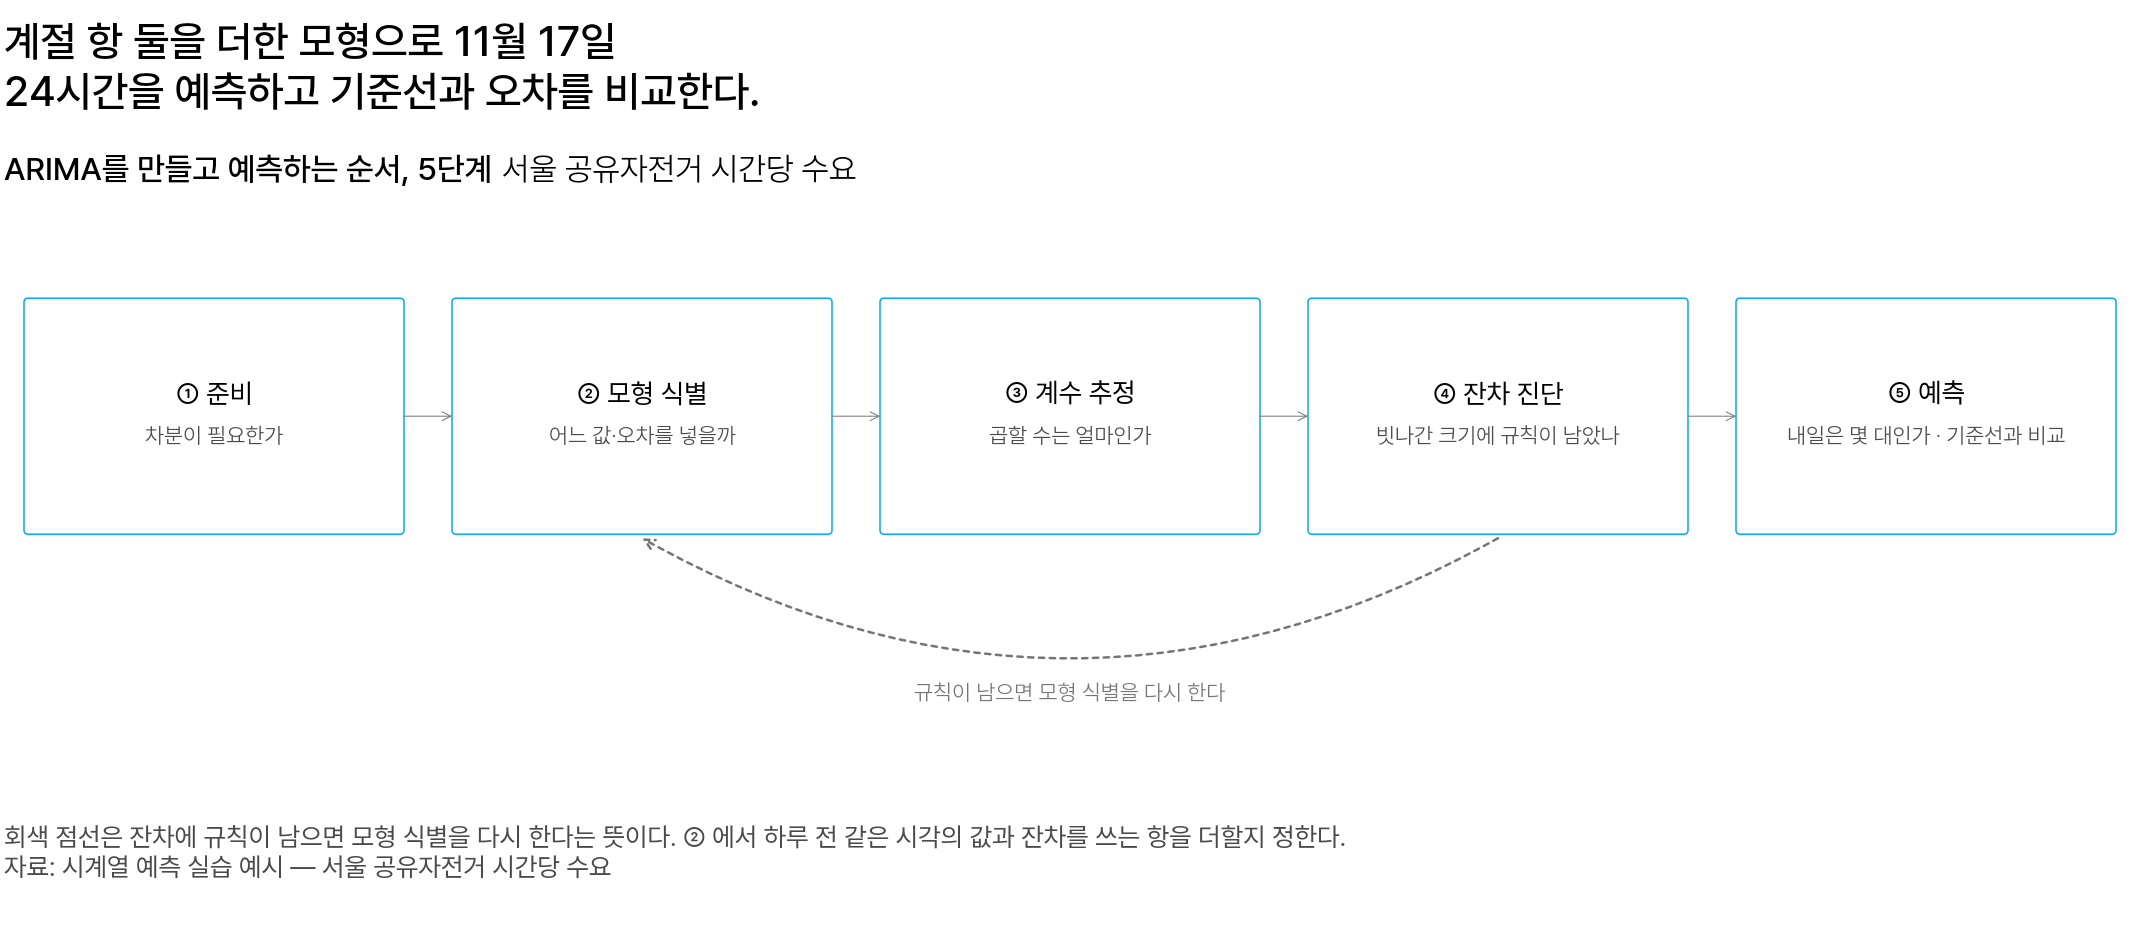

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 모형을 만들어 예측하는 다섯 단계. 잔차에 규칙이 남으면 모형 식별로 돌아간다</em></p>

어제 「후보 고르기」라고 부른 단계의 교과서 이름은 모형 식별입니다.

<div class="lms-summary">

**정리**

| 단계 | 서울 공유자전거에서 하는 일 |
|---|---|
| 준비 | 계절차분 1회, 레벨 차분 0회 |
| 모형 식별 | 하루 전 같은 시각의 항을 더할지 정한다 |
| 계수 추정 | 336시간으로 계수 4개를 구한다 |
| 잔차 진단 | 자기상관과 Ljung-Box 검정으로 규칙이 남았는지 본다 |
| 예측 | 11월 17일 24시간을 예측하고 가장 단순한 규칙과 견준다 |

어제 모형에 하루 전 같은 시각의 항을 더해 11월 17일 토요일 24시간을 예측합니다.

</div>

## 1. 주기 24 를 나타내는 계절 항 — SARIMA

어제 모형은 계절차분한 값을 한 시간 전의 값과 잔차로 예측했습니다. **SARIMA**(seasonal ARIMA)는 여기에 하루 전 같은 시각의 값과 잔차를 더 봅니다.

### SARIMA 가 더하는 두 항과 11월 17일 예측

#### 계절차분 뒤 ARIMA 만으로는 안 되는가

계절차분 뒤 ARIMA 인 어제 모형만으로도 예측은 됩니다. 다만 서울 공유자전거에서는 어제 모형의 예측에서 2가지, 잔차에서 2가지가 보입니다.

| 어제 모형에서 본 것 | 서울 공유자전거 값 | 뜻 |
|---|---|---|
| 17일 8시의 계절차분한 값 예측 | −2대 | 한 시간 전 값의 계수 0.814 를 9시간 곱해, 16일 23시 값의 영향이 $0.814^9 = 0.16$배만 남아 0 에 가깝다 |
| 17일 8시 대여량 예측(전날 같은 시각 실측 + 계절차분한 값 예측) | 16일 8시 실측 1,692 + (−2) = 1,690대 | 16일 금요일 8시에 우연히 더 나간 몫까지 17일 8시로 옮긴다 |
| 잔차의 시차 24 자기상관 | −0.33, 잔차 312개의 경계선 ±0.11 밖 | 전날 같은 시각에 예측보다 더 나갔으면 다음 날 같은 시각에는 덜 나가는 일이 많다 |
| 15일·16일 9시의 잔차 | +482대, −306대 | 부호가 반대다 |

표의 **경계선**은 계산한 자기상관이 우연인지 가르는 한계이고, 관측 $T$ 개면 $\pm 1.96/\sqrt{T}$ 입니다.

SARIMA 의 계절 항이 고치는 것은 이렇게 하루 우연히 더 나간 몫입니다. 17일이 토요일이라 평일보다 적게 나가는 차이는 SARIMA 도 담지 못합니다. 그 차이는 1주일 전 값을 쓰는 계절 나이브 168 과 오차를 비교해 확인합니다.

아래 셀로 −0.33 과 1,690대를 확인합니다.

In [ ]:
# 어제 모형(계절차분 뒤 ARIMA(1, 0, 1))의 잔차와 11월 17일 8시 예측을 본다
import warnings
warnings.filterwarnings("ignore")                                # statsmodels 안내문이 결과를 가리지 않게 한다
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf

try:
    raw = load_csv("datasets/SeoulBikeData.csv")                 # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                                # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.index = (pd.to_datetime(raw["Date"], format="%d/%m/%Y")      # 01/12/2017 = 2017년 12월 1일
             + pd.to_timedelta(raw["Hour"], unit="h"))           # 그 행의 시각을 더한다
raw = raw.sort_index()
hourly = raw["Rented Bike Count"].astype(float).mask(raw["Functioning Day"].eq("No"))
hourly = hourly.fillna(hourly.shift(24 * 7))                     # 운영을 멈춘 시각은 1주일 전 같은 시각으로 채운다
demand = hourly.loc["2018-11-03":"2018-11-16"]                   # 학습 구간 336시간
demand.index.freq = "h"

yday = SARIMAX(demand, order=(1, 0, 1), seasonal_order=(0, 1, 0, 24)).fit(disp=False)
e = yday.resid[24:]                                              # 앞 24시각을 뺀 잔차 312개
r24 = acf(e, nlags=24, fft=False)[24]                            # 24시간 떨어진 잔차끼리의 자기상관
phi = yday.params["ar.L1"]                                       # 한 시간 전 계절차분한 값에 곱하는 계수
fc = yday.get_forecast(24).predicted_mean                        # 11월 17일 0～23시
friday = demand["2018-11-16 08:00"]                              # 16일 금요일 8시 실측
print(f"어제 모형의 17일 8시 예측 {fc.iloc[8]:,.0f}대  |  16일 금요일 8시 실측 {friday:,.0f}대를 거의 그대로 옮긴다")
print(f"잔차의 시차 24 자기상관 {r24:.2f}  |  경계선 ±{1.96 / len(e) ** 0.5:.2f}")
print(f"잔차 11월 15일 9시 {yday.resid['2018-11-15 09:00']:+,.0f}대  |  16일 9시 {yday.resid['2018-11-16 09:00']:+,.0f}대")
print(f"한 시간 전 값의 계수 {phi:.3f}  |  9시간 동안 곱하면 {phi ** 9:.2f}")
assert round(r24, 2) == -0.33
assert round(phi, 3) == 0.814 and round(phi ** 9, 2) == 0.16
assert abs(yday.resid["2018-11-15 09:00"] - 482) < 3 and abs(yday.resid["2018-11-16 09:00"] + 306) < 3
assert abs(fc.iloc[8] - demand["2018-11-16 08:00"]) < 5          # 금요일 8시를 거의 그대로 옮긴다

SARIMA 는 잔차에 남은 24시간 간격의 규칙을 담는 항 둘(하루 전 같은 시각의 값과 잔차)을 더합니다.

계절차분(seasonal difference)은 이번 시각의 값에서 한 주기 전 같은 시각의 값을 빼는 계산입니다. 어제 모형에 이미 들어 있던 계산입니다.

$$
\underbrace{y'_t}_{\text{계절차분한 값}} = \underbrace{y_t}_{\text{이번 시각의 값}} - \underbrace{y_{t-m}}_{\text{한 주기 전 같은 시각의 값}}
$$

$m$ 은 한 주기의 관측 수이고, 시간별 하루 주기면 24 입니다. 아래 SARIMA 식의 $y'_t$ 가 이것입니다. 16일 8시라면 $y_t$ 가 1,692, $y_{t-24}$ 가 15일 8시의 1,686 이고, $y'_t = 1{,}692 - 1{,}686 = +6$ 대/시간입니다.

같은 시각끼리 빼면 시각에 따라 생기는 차이가 지워집니다. 16일 8시와 4시의 대여량은 1,692대와 171대로 1,521대 차이 납니다. 계절차분한 값은 +6대와 +17대로 둘 다 0 근처입니다. 남는 것은 전날보다 늘었는지 줄었는지뿐입니다.

SARIMA 가 16일 금요일 8시를 예측할 때 보는 과거는 아래 표와 같습니다(잔차는 SARIMA 의 값). 17일 8시는 한 시간 전인 17일 7시가 아직 관측되지 않아, 네 항의 값이 모두 실측인 16일 8시로 봅니다.

| 항($t$ = 16일 8시) | 16일 8시를 예측할 때 보는 값 | 이 항이 묻는 것 | 서울 공유자전거 계수 |
|---|---|---|---|
| 한 시간 전 값 $y'_{t-1}$ (어제도 있음) | 16일 7시의 계절차분한 값 +56대 | 한 시간 전의 흐름이 이어질까 | $\phi_1 = 0.79$. 어제는 0.814 였고, 계절 항을 더해 다시 맞춰 바뀌었다 |
| 한 시간 전 잔차 $\varepsilon_{t-1}$ (어제도 있음) | 16일 7시 잔차 +105대(예측 834대, 실측 939대) | 방금 빗나간 방향이 이어질까 | $\theta_1 = 0.24$ |
| **하루 전 같은 시각의 값 (새 항)** $y'_{t-24}$ | 15일 8시의 계절차분한 값: 15일 8시 1,686 − 14일 8시 1,916 = −230대 | 전날 같은 시각의 흐름이 이어질까 | $\Phi_1 = 0.175$. 조금만 이어 간다 |
| **하루 전 같은 시각의 잔차 (새 항)** $\varepsilon_{t-24}$ | 15일 8시 잔차 +208대(예측 1,478대, 실측 1,686대) | 전날 같은 시각에 빗나간 만큼을 고칠까 | $\Theta_1 = -0.99$. 거의 다 뺀다 |

예측할 시각이 한 시간 늦어지면 보는 과거도 모두 한 시간씩 늦어집니다. 16일 9시 $y'_{t+1}$ 을 예측할 때는 16일 8시 $y'_t$ 와 15일 9시 $y'_{t-23}$, 두 시각의 잔차를 봅니다.

하루 전 같은 시각의 잔차 항은 전날 같은 시각에 빗나간 크기에 계수를 곱해 오늘 예측에 더합니다.

| 경우 | 전날 8시 예측 → 실측 | 잔차 | 계수 | 오늘 8시 예측에 더하는 몫 |
|---|---|---|---|---|
| 쉬운 수로 예를 들면 | 1,500대 → 1,700대 | +200대 | −0.5 | −0.5 × 200 = −100대 |
| 서울 공유자전거(16일 8시 → 17일 8시) | 1,524.6대 → 1,692대 | +167.4대 | −0.99 | −0.99 × 167.4 ≈ −166대 |

계수가 −0.5 면 전날 더 나간 몫의 절반을, 서울 공유자전거의 −0.99 면 거의 다 뺍니다.

계절차분과 새 항은 둘 다 하루 전 같은 시각을 쓰지만 하는 일이 다릅니다. 계절차분은 예측할 대상을 대여량 1,692대에서 전날보다 늘어난 양 +6대로 바꿉니다. 새 항 둘은 그 +6대를 예측할 때 쓸 과거 정보를 더합니다. 그래서 모형이 예측하는 것은 계절차분한 값이고, 대여량 예측은 마지막에 전날 같은 시각의 실측을 더해 복원합니다.

$$
\hat{y}_t = y_{t-24} + \hat{y}'_t
$$

$\hat{y}_t$ 는 대여량 예측, $y_{t-24}$ 는 전날 같은 시각의 실측, $\hat{y}'_t$ 는 계절차분한 값의 예측입니다.

어제 식과 오늘 식을 위아래로 적으면 오늘 더한 항 둘(파랑)이 보입니다.

$$
\begin{aligned}
\text{어제: } y'_t &= \phi_1 y'_{t-1} + \varepsilon_t + \theta_1 \varepsilon_{t-1} \\
\text{오늘: } y'_t &= \phi_1 y'_{t-1} + \varepsilon_t + \theta_1 \varepsilon_{t-1} \\
&\quad + {\color{#1f6feb}\Phi_1 y'_{t-24} + \Theta_1 \varepsilon_{t-24}}
\end{aligned}
$$

- $y'_t$ : 계절차분한 값입니다. 어제는 같은 기호를 레벨 차분한 값에 썼지만, 어제 모형도 계절차분한 값에 맞췄으니 두 식의 $y'_t$ 는 같습니다.
- $\varepsilon_t$ : 오차항입니다. 예측하는 순간에는 모르는 값이라 0 으로 둡니다. 실측이 나온 뒤 실측에서 예측을 뺀 값이 잔차입니다.
- $\Phi_1 y'_{t-24}$ : 하루 전 같은 시각의 계절차분한 값에 곱하는 항이라 **계절 자기회귀(AR) 항**입니다.
- $\Theta_1 \varepsilon_{t-24}$ : 하루 전 같은 시각의 오차항에 곱하는 항이라 **계절 이동평균(MA) 항**입니다. 따로 계절 오차가 있는 것이 아니라, 같은 모형의 잔차를 24시간 전 시각에서 가져옵니다.

오늘 식은 한 시간 전 항과 하루 전 같은 시각의 항만 남겨 줄여 적었습니다. 실제 모형에는 25시간 전 항이 하나 더 있고, 아래 17일 0시 계산의 다섯째 몫이 이 항입니다.

17일 8시 대여량 예측은 16일 8시 실측 1,692대에 계절차분한 값의 예측 −344대를 더한 1,348대입니다. 이 예측을 가장 크게 낮춘 것은 하루 전 같은 시각의 잔차 항(−166대)입니다. 16일 금요일 8시에 우연히 더 나간 몫을 거의 다 뺀 것입니다. 항마다 나눈 값은 아래 「자세히」 표에 있습니다.

<details class="lms-extra"><summary>자세히 — 16일 8시와 17일 8시 예측을 항마다 나누면</summary>

**16일 8시: 네 항의 값이 모두 실측인 시각**

336시간에 맞춘 계수 넷으로 16일 8시를 예측하면 항마다 이만큼을 더합니다.

| 항 | 기호 | 계수 × 곱하는 값 = 더하는 몫 |
|---|---|---|
| 한 시간 전의 계절차분한 값 | $\phi_1$ | 0.79 × 56 = +44대 |
| 한 시간 전 잔차 | $\theta_1$ | 0.24 × 105 = +25대 |
| 하루 전 같은 시각의 계절차분한 값 | $\Phi_1$ | 0.175 × (−230) = −40대 |
| 하루 전 같은 시각의 잔차 | $\Theta_1$ | −0.99 × 208 = −206대 |

네 몫을 15일 8시 실측 1,686대에 더하면 약 1,510대로, statsmodels 예측 1,525대보다 15대 적습니다. 16일 8시에도 25시간 전(15일 7시)의 몫이 있지만 +0.6대뿐이라 이 차이의 원인이 아닙니다.

손계산은 과거 오차항 대신 잔차를 그대로 씁니다. statsmodels 는 자료가 시작되기 전의 값을 모른다는 점까지 반영해 과거 오차항을 다시 추정해 씁니다. 이 차이는 자료가 쌓일수록 줄어듭니다.

---

**17일 8시: 한 시간 전 값이 예측인 시각**

17일 7시는 아직 관측되지 않았습니다. 그래서 한 시간 전 값으로 17일 7시의 예측 −199.5대를 쓰고, 17일 7시의 잔차는 모르는 값이라 0 으로 둡니다. 계절차분한 값의 예측 −344대를 항마다 나누면 이렇습니다.

| 항 | 계수 × 곱하는 값 = 더하는 몫 |
|---|---|
| 하루 전 같은 시각(16일 8시)의 잔차 | −0.99 × 167.4 = −166대 |
| 한 시간 전(17일 7시 예측)의 값 | 0.79 × (−199.5) = −158대 |
| 한 시간 전(17일 7시)의 잔차 | 0.24 × 0 = 0대 |
| 하루 전 같은 시각(16일 8시)의 값 | 0.175 × 6 = +1대 |
| 25시간 전(16일 7시)의 값 | −0.14 × 56 = −8대 |
| 25시간 전(16일 7시)의 잔차 | −0.24 × 105 = −25대 |
| statsmodels 계산과 손계산의 차이 | +12대 |

일곱 몫을 더하면 −344대입니다. 25시간 전 몫에 곱하는 −0.14 와 −0.24 는 한 시간 전 항의 계수와 하루 전 같은 시각 항의 계수를 곱해 나온 수입니다. 값 쪽은 그 곱의 부호를 바꿉니다. 마지막 +12대는 16일 8시의 15대 차이와 같은 까닭으로 생깁니다.

17일 7시의 예측 −199.5대도 같은 방식으로 나온 값입니다. 16일 6시·7시에 예측보다 더 나간 +111대·+105대를 계절 이동평균 항이 거의 다 빼고, 그 몫이 한 시간씩 이어져 누적되었습니다.

</details>

손계산은 한 시간 전(16일 23시)이 실측인 17일 0시로 합니다. 아래 셀은 계수 넷으로 17일 0시를 손으로 예측해 statsmodels 예측과 비교합니다.

In [ ]:
# 계수 넷으로 11월 17일 0시의 계절차분한 값을 예측하고, 16일 0시 실측에 더해 statsmodels 예측과 견준다
import warnings
warnings.filterwarnings("ignore")                                # statsmodels 안내문이 결과를 가리지 않게 한다
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    raw = load_csv("datasets/SeoulBikeData.csv")                 # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                                # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.index = (pd.to_datetime(raw["Date"], format="%d/%m/%Y")      # 01/12/2017 = 2017년 12월 1일
             + pd.to_timedelta(raw["Hour"], unit="h"))           # 그 행의 시각을 더한다
raw = raw.sort_index()
hourly = raw["Rented Bike Count"].astype(float).mask(raw["Functioning Day"].eq("No"))
hourly = hourly.fillna(hourly.shift(24 * 7))                     # 운영을 멈춘 시각은 1주일 전 같은 시각으로 채운다
demand = hourly.loc["2018-11-03":"2018-11-16"]                   # 학습 구간 336시간
demand.index.freq = "h"

res = SARIMAX(demand, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24)).fit(disp=False)   # 브라우저에서 10초 남짓
phi, theta = res.params["ar.L1"], res.params["ma.L1"]            # 한 시간 전 항에 곱하는 수
Phi, Theta = res.params["ar.S.L24"], res.params["ma.S.L24"]      # 하루 전 같은 시각 항에 곱하는 수
z = demand - demand.shift(24)                                    # 계절차분한 값(본문의 y′)
e = res.resid                                                    # 빗나간 크기 = 실측 − 한 시각 앞 예측
miss = e["2018-11-15 08:00"]                                     # 새 항 하나: 15일 8시에 빗나간 크기

parts = {                                                        # 계절차분한 값의 예측을 이루는 몫 다섯(과거 값 × 계수)
    f"한 시간 전(16일 23시)의 값 {z['2018-11-16 23:00']:+.0f}대 × {phi:.2f}":
        phi * z["2018-11-16 23:00"],
    f"한 시간 전(16일 23시)의 잔차 {e['2018-11-16 23:00']:+.0f}대 × {theta:.2f}":
        theta * e["2018-11-16 23:00"],
    f"하루 전 같은 시각(16일 0시)의 값 {z['2018-11-16 00:00']:+.0f}대 × {Phi:.3f}":
        Phi * z["2018-11-16 00:00"],
    f"하루 전 같은 시각(16일 0시)의 잔차 {e['2018-11-16 00:00']:+.0f}대 × {Theta:.2f}":
        Theta * e["2018-11-16 00:00"],
    "25시간 전(15일 23시)의 값과 잔차":
        (-phi * Phi * z["2018-11-15 23:00"] + theta * Theta * e["2018-11-15 23:00"]),
}
z_hat = sum(parts.values())                                      # 계절차분한 값의 예측(본문의 ŷ′)
base = demand["2018-11-16 00:00"]                                # 하루 전 같은 시각 실측(16일 0시)
hand = base + z_hat                                              # 대여량 예측 = 전날 같은 시각 실측 + 계절차분한 값의 예측
model = res.get_forecast(1).predicted_mean.iloc[0]

print(f"17일 0시 대여량 예측 {hand:,.0f}대 = 16일 0시 실측 {base:,.0f}대 + 계절차분한 값의 예측 ({z_hat:+,.0f}대)")
print(f"계절차분한 값의 예측 {z_hat:+,.0f}대 = 아래 몫 다섯의 합")
for name, val in parts.items():
    print(f"{val:+6.0f}대  {name}")
print(f"검산: statsmodels 예측 {model:,.0f}대, 손계산과의 차이 {model - hand:+.0f}대")

z_fc = res.get_forecast(24).predicted_mean - demand.loc["2018-11-16"].to_numpy()   # 17일 계절차분한 값의 예측
new = Theta * e["2018-11-16 08:00"]                              # 새 항: 16일 8시 잔차 × 하루 전 같은 시각 잔차의 계수
prev = phi * z_fc.iloc[7]                                        # 한 시간 전 값: 17일 7시의 예측 × 한 시간 전 값의 계수
assert round(Theta * miss) == -206
assert abs(z_hat + 31) < 3                                       # 계절차분한 값의 예측 −31대 근처
assert abs(hand - model) < 5
assert round(-phi * Phi, 2) == -0.14 and round(theta * Theta, 2) == -0.24   # 25시간 전 값·잔차에 곱하는 수
assert round(-phi * Phi * z["2018-11-15 23:00"]) == 5 and round(theta * Theta * e["2018-11-15 23:00"]) == 13
assert round(Theta * e["2018-11-16 08:00"]) == -166                # 17일 8시 예측에 더하는 새 항의 몫
assert round(res.get_forecast(24).predicted_mean.iloc[8]) == 1348   # SARIMA 의 17일 8시 예측
assert round(z_fc.iloc[8]) == -344 and round(prev) == -158 and round(z_fc.iloc[8] - new - prev) == -20
# 17일 8시의 −20대를 항마다 나눈 값(본문 접힘의 표)
assert round(Phi * z["2018-11-16 08:00"]) == 1                    # 하루 전 같은 시각(16일 8시)의 값
assert round(-phi * Phi * z["2018-11-16 07:00"]) == -8            # 25시간 전(16일 7시)의 값
assert round(theta * Theta * e["2018-11-16 07:00"]) == -25        # 25시간 전(16일 7시)의 잔차
assert round(z_fc.iloc[8] - new - prev - Phi * z["2018-11-16 08:00"]
             + phi * Phi * z["2018-11-16 07:00"] - theta * Theta * e["2018-11-16 07:00"]) == 12   # statsmodels 계산과의 차이

앞 셀 출력의 첫 행이 손계산한 17일 0시 대여량 예측 652대이고, 마지막 행의 statsmodels 예측 654대와 2대만 다릅니다. 몫 다섯 가운데 넷은 계수 넷의 몫입니다. 「25시간 전(15일 23시)의 값과 잔차」 행의 +18대는 줄여 적은 식에 없던 25시간 전 항의 몫입니다.

#### 왜 25시간 전 값이 식에 들어오는가

식에서 값에 곱하는 항은 한 시간 전 값에 곱하는 $\phi_1$ 항과 하루 전 같은 시각의 값에 곱하는 $\Phi_1$ 항 둘입니다. 두 항의 몫을 따로 더한다고 보면 25시간 전 값은 필요 없어 보입니다.

그런데 하루 전 값 전체를 더하면 직전 시각에서 이어진 몫을 두 번 더합니다. 그래서 SARIMA 의 계절 AR 항은 하루 전 값에서 그 직전 시각에서 이어진 몫을 뺀 차이만 가져옵니다.

17일 0시를 예측한다면 이 차이는 16일 0시 값에서 15일 23시 값으로 예측되는 몫을 뺀 값입니다. 15일 23시는 17일 0시에서 25시간 전입니다.

계수를 모두 1 로 두고 쉬운 수로 두 방법을 나란히 계산합니다. 계절차분한 값이 15일 23시 40, 16일 0시 30, 16일 23시 20 이라 하겠습니다.

| 방법 | 17일 0시 예측 | 하루 전에서 가져온 것 | 직전 시각에서 이어진 몫 |
|---|---|---|---|
| 하루 전 값 전체를 더하기 | 20 + 30 = 50 | 16일 0시 값 30 전체 | 두 번 더한다. 16일 23시의 20 과, 30 안에 이미 든 15일 23시 40 의 몫 |
| 하루 전 차이만 가져오기(SARIMA) | 20 + (30 − 40) = 10 | 16일 0시 값 30 에서 15일 23시 값 40 을 뺀 차이 −10 | 한 번 더한다. 16일 23시의 20 만 |

위 코드 셀 출력에서 「하루 전 같은 시각(16일 0시)의 값」 행은 쉬운 수의 30 에서 나온 몫입니다. 「25시간 전(15일 23시)의 값과 잔차」 행은 쉬운 수의 40 에서 나온 몫입니다.

서울 공유자전거에서는 25시간 전 값에 곱하는 수가 −0.14 입니다. 15일 23시의 계절차분한 값이 1대 크면 17일 0시 예측은 0.14대 낮아진다는 뜻입니다. 이 수는 두 계수를 곱해 나오므로, 이런 SARIMA 를 곱셈 계절 모형이라고도 부릅니다.

그래서 하루 전 값에서 직전 시각의 몫을 빼는 과정에 25시간 전 값이 쓰여 식에 들어옵니다.

<details class="lms-extra"><summary>자세히 — 실제 계수로 계산한 25시간 전 몫, 식과 오차항 쪽의 부호</summary>

**쉬운 수에 실제 계수를 대입하면**

한 시간 전 값의 계수 $\phi_1 = 0.79$, 하루 전 같은 시각 값의 계수 $\Phi_1 = 0.175$ 로 같은 쉬운 수를 계산해도 순서는 같습니다.

1. 15일 23시에서 16일 0시로 이어진 몫을 곱합니다: $0.79 \times 40 = 31.6$
2. 16일 0시 값에서 그 몫을 뺍니다: $30 - 31.6 = -1.6$
3. 16일 23시에서 이어진 몫을 곱합니다: $0.79 \times 20 = 15.8$
4. 16일 0시의 차이에 하루 전 같은 시각 값의 계수를 곱합니다: $0.175 \times (-1.6) = -0.28$
5. 두 몫을 더합니다: $15.8 + (-0.28) = 15.52$

넷째 단계의 −1.6 은 30 − 31.6 이므로, 0.175 를 30 과 −31.6 에 나누어 곱하면 25시간 전 값 40 에 곱해지는 수가 따로 보입니다.

1. 16일 0시 값의 몫을 곱합니다: $0.175 \times 30 = 5.25$
2. 25시간 전 값의 몫을 곱합니다: $0.175 \times (-31.6) = -5.53$
3. 세 몫을 더합니다: $15.8 + 5.25 + (-5.53) = 15.52$

−31.6 은 $-0.79 \times 40$ 이라, 40 에 곱해진 수는 $-0.79 \times 0.175 = -0.138$, 약 −0.14 입니다. 이 수가 25시간 전 값에 곱하는 수입니다.

---

**식으로 보기**

AR 항($\phi_1$)으로 예측하고 남은 차이는 $y'_t - \phi_1 y'_{t-1}$ 입니다. 계절 AR 항은 이 차이가 하루 전 같은 시각의 차이와 $\Phi_1$ 만큼 이어진다고 둡니다(오차항은 빼고 적습니다).

$$
y'_t - \phi_1 y'_{t-1} = \Phi_1 (y'_{t-24} - \phi_1 y'_{t-25})
$$

오른쪽 괄호가 쉬운 수의 $30 - 0.79 \times 40$ 입니다. $\Phi_1$ 을 괄호 안 두 항에 나누어 곱하고, 양쪽에 $\phi_1 y'_{t-1}$ 을 더합니다.

$$
y'_t = \phi_1 y'_{t-1} + \Phi_1 y'_{t-24} - \phi_1 \Phi_1 y'_{t-25}
$$

25시간 전 값에 $-\phi_1 \Phi_1$ 이 곱해집니다.

오차항 쪽도 같은 방식으로 두 항이 곱해집니다. 다만 식이 오차항을 빼지 않고 더하는 형태($\varepsilon_t + \theta_1 \varepsilon_{t-1}$)라, 25시간 전 오차항에는 $+\theta_1 \Theta_1$ 이 곱해집니다.

$$
\begin{aligned}
&(\varepsilon_t + \theta_1 \varepsilon_{t-1}) + \Theta_1 (\varepsilon_{t-24} + \theta_1 \varepsilon_{t-25}) \\
&= \varepsilon_t + \theta_1 \varepsilon_{t-1} + \Theta_1 \varepsilon_{t-24} + \theta_1 \Theta_1 \varepsilon_{t-25}
\end{aligned}
$$

값 쪽은 $-\phi_1 \Phi_1$, 오차항 쪽은 $+\theta_1 \Theta_1$ 로 적는 형태가 다릅니다. 서울 모형은 $\Theta_1$ 이 음수라 $\theta_1 \Theta_1 = 0.24 \times (-0.99) = -0.24$ 입니다. 그래서 $-\phi_1 \Phi_1 = -0.14$ 와 같은 음수로 나옵니다.

---

**17일 0시의 25시간 전 몫**

17일 0시에서는 15일 23시의 계절차분한 값 −36대에 −0.14 를 곱한 +5대가 값 쪽 몫입니다. 같은 시각 잔차 −54대에 −0.24 를 곱한 +13대가 잔차 쪽 몫이고, 둘을 더하면 위 코드 셀 출력의 25시간 전 몫 +18대입니다.

</details>

항의 개수와 주기까지 적은 이름은 $\text{SARIMA}(p, d, q)(P, D, Q)_m$ 입니다. 오늘 모형 **SARIMA(1, 0, 1)(1, 1, 1)$_{24}$** 의 앞 괄호는 어제의 (1, 0, 1) 그대로입니다. 뒤 괄호의 세 수는 이렇습니다.

- $P = 1$: 계절 자기회귀 항 1개
- $D = 1$: 계절차분 1회
- $Q = 1$: 계절 이동평균 항 1개

아래 첨자 24 가 하루의 관측 수인 주기 $m$ 이고, 괄호 안 6개와 합쳐 숫자 7개로 모형이 정해집니다.

#### 계절 주기 m(seasonal period): 한 번 되풀이되는 데 드는 관측 수

계절 주기 $m$ 은 같은 모양이 한 번 되풀이되는 동안 들어가는 관측의 개수입니다. 그래서 같은 하루 주기라도 관측 간격이 바뀌면 $m$ 이 달라집니다.

| 관측 간격 | 나타내려는 주기 | $m$ |
|---|---|---|
| 월별 | 1년 | 12 |
| **시간별** | **하루** | **24** |
| 시간별 | 1주일 | 168 |

**서울 공유자전거는 $m = 24$ 이고, 이것을 주기 24 라고 부릅니다.**

계절 항이 없으면 $p$ 를 24 로 두어 계수 24개를 맞춰야 하지만, 계절 항은 계수 하나로 24시간 전을 봅니다.

### 숫자 7개를 정한 까닭

SARIMA 의 숫자도 둘째 날 ARIMA 차수를 정한 순서 그대로 정합니다. 다른 점은 계절 차수 $P$, $D$, $Q$ 를 시차 24·48 자리에서 본다는 것입니다.

| 순서 | 둘째 날 ARIMA $(p, d, q)$ | SARIMA 에 더하는 $(P, D, Q)_m$ | 서울 공유자전거 |
|---|---|---|---|
| ① 주기 | 없음 | 한 번 되풀이되는 관측 수 $m$ | $m = 24$ |
| ② 차분 | 단위근 검정으로 $d$ 를 정한다 | 하루 모양이 같은 크기로 되풀이된다고 보면 계절차분 $D = 1$(많아야 1) | $D = 1$, ADF −17.0 → $d = 0$ |
| ③ 후보 | 자기상관함수·부분자기상관함수가 끊기는 시차로 $q$·$p$ 후보 | 계절차분한 값의 같은 두 그림에서 시차 24·48 막대로 $Q$·$P$ 후보 | 자기상관 시차 24 −0.40 → $Q = 1$ |
| ④ 고르기 | 차분이 같은 후보끼리 AIC | ARIMA 와 같다 | $P = 0$ 이면 4,163.3, $P = 1$ 이면 4,159.3 → $P = 1$ |
| ⑤ 확인 | 잔차 진단 | ARIMA 와 같다 | 잔차 자기상관과 Ljung-Box 검정 |

③ 행의 −0.40 은 계절차분한 값 자체의 시차 24 자기상관입니다. 앞에서 본 −0.33 은 어제 모형 잔차의 자기상관이라 계열이 다릅니다. 차수를 고를 때는 모형을 맞추기 전의 계절차분한 값을 봅니다.

둘째 날 자동 차수 탐색(`auto_arima(seasonal=True, m=24)`)은 같은 336시간에서 (1, 0, 1)(1, 0, 1)$_{24}$ 를 반환했습니다. 표와 다른 수는 계절차분 횟수 $D$ 하나입니다.

그런데 서울 공유자전거 수요에는 주기가 하나 더 있습니다.

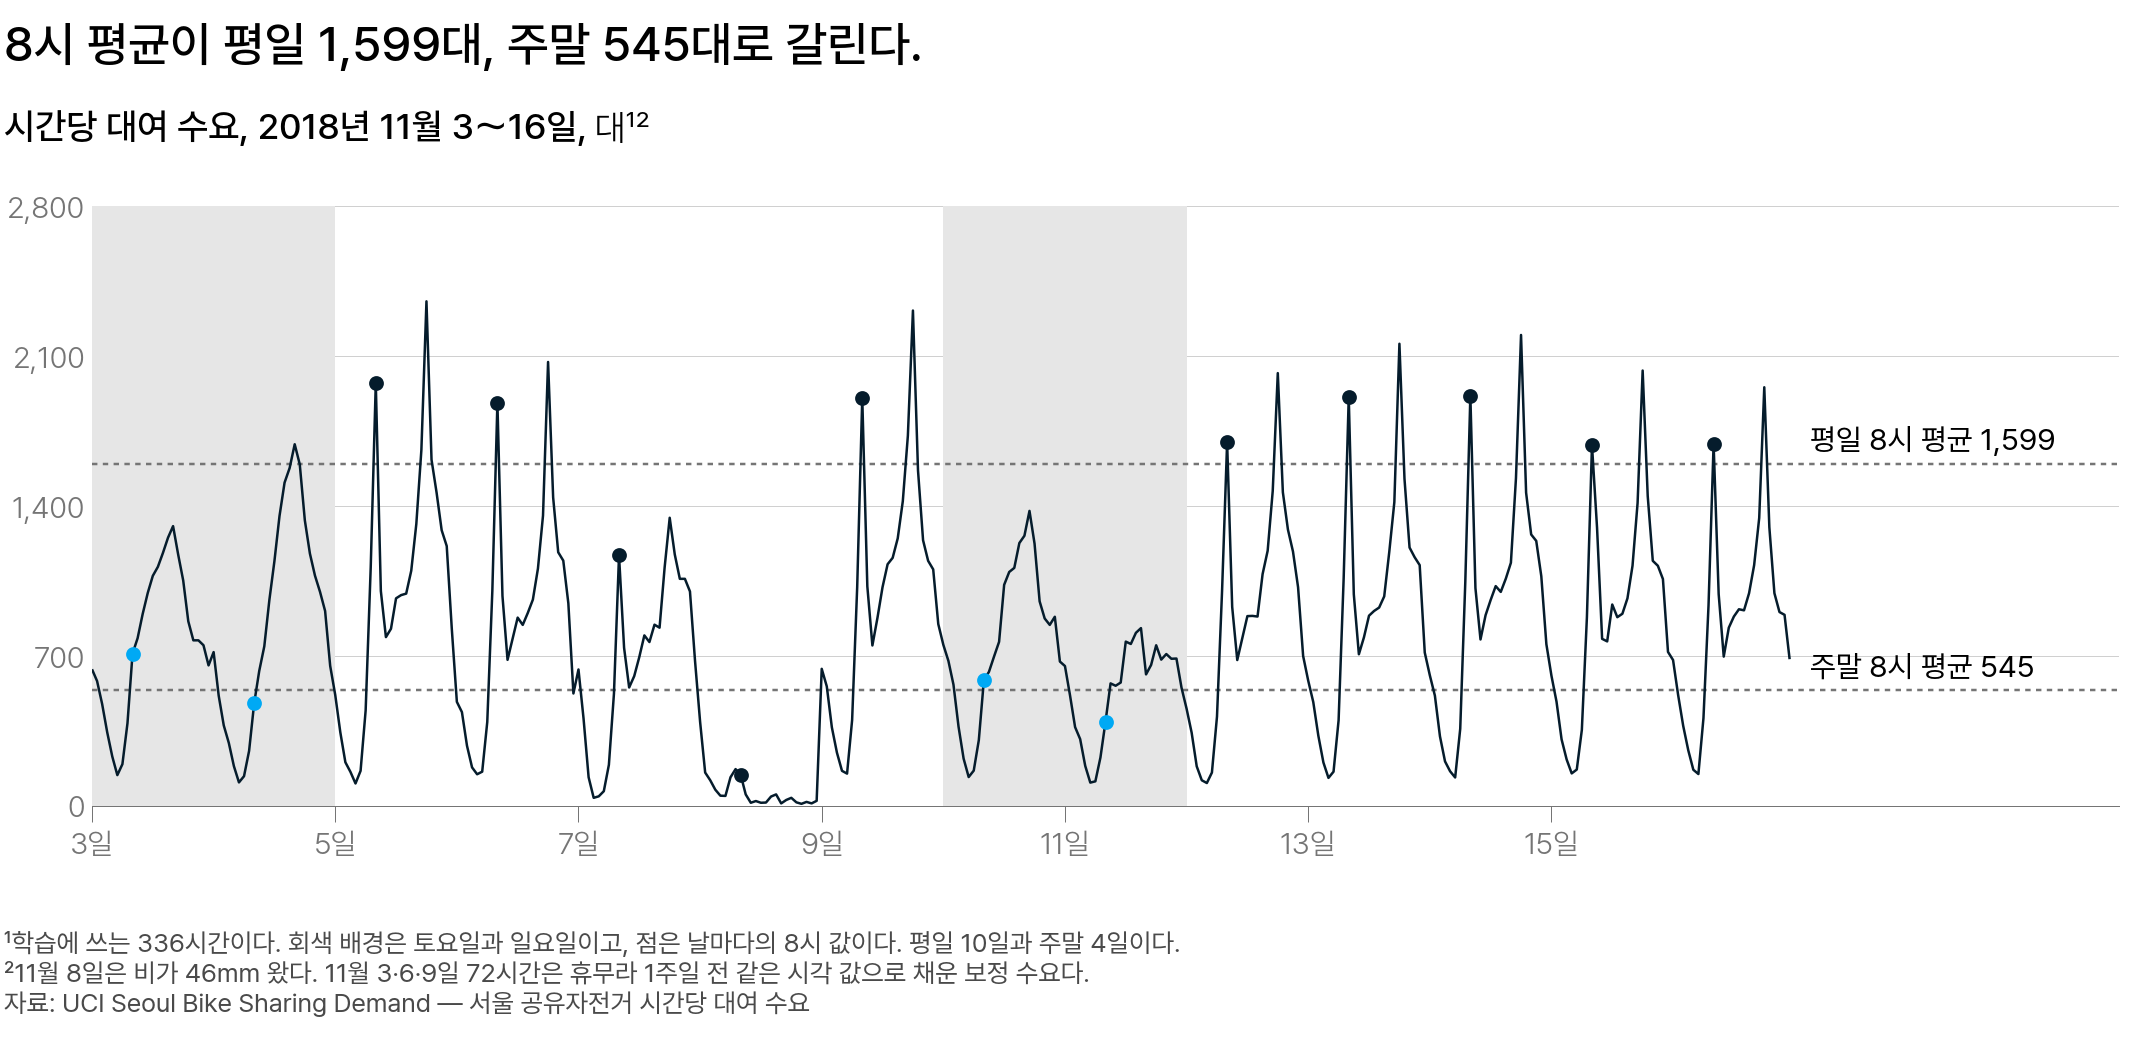

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 11월 3～16일 336시간의 시간당 수요. 회색 배경인 토·일 네 날은 8시 값이 평일보다 낮고, 비가 46mm 온 11월 8일은 하루 내내 낮다</em></p>

가로축이 날짜이고 세로축이 시간당 대여 수요입니다. 점은 날마다의 8시 값이고 하늘색 점이 주말입니다. 흰 배경의 평일에는 8시와 18시에 수요가 많습니다.

- 평일 8시: 평균 1,599대
- 주말 8시: 평균 545대
- 주말에 가장 많은 시각: 15시, 시각별 평균 1,224대

같은 8시라도 평일과 주말이 다르고, 이 차이는 168시간(7일)마다 되풀이됩니다. 그래서 서울 공유자전거 수요에는 하루 주기 24 와 1주일 주기 168 이 함께 있습니다.

#### 왜 주기 168 이 아니라 주기 24 를 고르는가

계절차분도 계절 항도 $m$ 시간 전을 보므로 $m$ 을 가장 먼저 정합니다. SARIMA 에는 주기를 적는 $m$ 이 하나뿐이라, 두 주기 가운데 하나만 적습니다.

| 주기 | 11월 12일 월요일 8시(실측 1,699대)를 예측할 때 보는 값 | 계절차분할 때 한 주기 전 값이 없어 빠지는 학습 시간 |
|---|---|---|
| $m = 24$ | 11일 일요일 8시 395대 | 맨 앞 24시간 |
| $m = 168$ | 5일 월요일 8시 1,975대. 요일이 같아 실측에 더 가깝다 | 맨 앞 168시간. 학습 336시간의 절반 |

1주일 전 값이 실측에 더 가깝지만 168 로 두면 학습 자료의 절반을 잃어, 오늘 모형은 $m = 24$ 로 둡니다. 하루 주기와 1주일 주기를 함께 담는 Prophet 은 다섯째 날에 다룹니다.

<details class="lms-extra"><summary>자세히 — 주기가 둘인 계열: 성분 둘의 합, SARIMA 밖에서 주기 168 을 함께 쓰는 방법</summary>

<img src="https://www.statsmodels.org/stable/_images/examples_notebooks_generated_statespace_seasonal_5_0.png" width="640" height="319"/>
<p align="center"><em>▲ 주기 10 의 성분(주황)과 주기 100 의 성분(초록)을 더하면 파랑 total 이 된다. 빨강 level 은 10 으로 고정된 수준이라, 세로축이 −1,000～500 눈금인 이 그림에서는 0 선처럼 보인다 (출처: statsmodels 계절 모형 예제)</em></p>

주기가 둘인 계열은 이렇게 성분 둘의 합으로 볼 수 있습니다. 가로축이 관측 순서이고 세로축이 값입니다.

- 주황 10(3): 관측 10개마다 같은 모양을 되풀이하는 성분
- 초록 100(2): 관측 100개마다 되풀이하는 성분
- 파랑 total: 두 성분에 고정 수준 10 을 더한 값

괄호 안의 수는 그 성분을 만들 때 더한 사인파의 개수입니다. 사인파는 같은 간격으로 오르내리기를 되풀이하는 매끈한 곡선입니다. 서울 수요의 주기 24 와 168 이 이 두 성분에 해당합니다.

---

주기 168 을 함께 쓰려면 $m$ 이 하나 더 필요한데 SARIMA 에는 $m$ 이 하나뿐입니다. 자주 쓰는 방법 하나가 동적 조화 회귀(dynamic harmonic regression)입니다. 주기 168 을 사인·코사인 항 몇 개로 만들어 같은 모형에 외부 회귀변수로 씁니다([fpp3 12.1](https://otexts.com/fpp3/complexseasonality.html)).

외부 회귀변수는 모형 밖에서 가져와 설명 변수로 함께 쓰는 열입니다. 여기서 쓰는 열은 168시간마다 한 번 오르내리는 사인파와, 그 곡선을 42시간 옮긴 코사인입니다.

</details>

#### 왜 시간당 대여 수요는 계절차분만 하고 레벨 차분은 하지 않는가

주기를 24 로 정한 다음에는 차분 횟수 $D$ 와 $d$ 를 정하고, 계절차분 횟수 $D$ 부터 봅니다. 이 모형은 첫날 정하고 어제 모형에도 쓴 계절차분을 그대로 두어 $D = 1$ 입니다.

그런데 둘째 날 자동 차수 탐색은 같은 336시간에서 $D = 0$ 을 골랐습니다. 탐색 안의 계절 단위근 검정(OCSB, 만든 연구자 넷의 머리글자)이 계절차분은 필요 없다고 보았기 때문입니다. 이 모형은 검정 결과와 반대로 가는 것처럼 보입니다.

첫날 다룬 단위근은 직전 값에 곱하는 수가 정확히 1 인 상태였고, 계절 단위근은 전날 같은 시각의 값에 곱하는 수가 1 인 상태입니다. 검정은 336시간에서 이 수를 1 로 보기 어렵다고 결론 내렸습니다. $D = 0$ 모형으로 맞추면 이 수는 0.97 입니다. 그래서 두 선택은 전날 같은 시각의 값을 몇 배 가져오느냐만 다릅니다.

| 비교 | 자동 탐색, $D = 0$ | 계절차분, $D = 1$ |
|---|---|---|
| 전날 같은 시각의 값을 가져오는 방법 | 대여량에 계절 자기회귀 계수 $\Phi_1 = 0.97$ 을 곱한다 | 빼서 예측한 뒤 마지막에 다시 더해($\hat{y}_t = y_{t-24} + \hat{y}'_t$), 1배 그대로 가져온다 |
| 전날 8시가 1,000대라면 하루 뒤 예측에 들어가는 값 | 970대 | 1,000대 |
| 날이 갈수록 | 0.97 을 날마다 다시 곱해, 1일째와 비교하면 7일째 $0.97^6 \approx 0.83$배, 30일째 $0.97^{29} \approx 0.41$배 | 날이 가도 1배 그대로 |
| 예측의 하루 모양 | 날마다 옅어진다 | 같은 크기로 되풀이된다 |

$D = 1$ 모형의 계절 자기회귀 계수 $\Phi_1 = 0.175$ 는 대여량이 아니라 계절차분한 값에 곱하는 수라, 0.97 과 곱하는 대상이 다릅니다.

아래 셀은 두 모형의 30일 예측에서 날마다 최댓값과 최솟값의 차인 하루 범위를 계산합니다. 1년 자료에서 운영한 평일의 8시 평균이 새벽 4시 평균의 몇 배인지도 달마다 계산합니다.

In [ ]:
# auto_arima 가 고른 D = 0 모형과 앞에서 맞춘 D = 1 모형으로 11월 17일부터 30일 동안을 예측해 하루 범위를 견주고,
# 1년 자료에서 운영한 평일의 8시 평균이 새벽 4시 평균의 몇 배인지 달마다 본다
import warnings
warnings.filterwarnings("ignore")                                # statsmodels 안내문이 결과를 가리지 않게 한다
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    raw = load_csv("datasets/SeoulBikeData.csv")                 # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                                # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.index = (pd.to_datetime(raw["Date"], format="%d/%m/%Y")      # 01/12/2017 = 2017년 12월 1일
             + pd.to_timedelta(raw["Hour"], unit="h"))           # 그 행의 시각을 더한다
raw = raw.sort_index()
hourly = raw["Rented Bike Count"].astype(float).mask(raw["Functioning Day"].eq("No"))
hourly = hourly.fillna(hourly.shift(24 * 7))                     # 운영을 멈춘 시각은 1주일 전 같은 시각으로 채운다
demand = hourly.loc["2018-11-03":"2018-11-16"]                   # 학습 구간 336시간
demand.index.freq = "h"

try:
    res                                                          # 계수 넷으로 17일 0시를 예측한 셀에서 맞춘 D = 1 모형
except NameError:                                                # 그 셀을 건너뛰었으면 같은 차수로 다시 맞춘다
    res = SARIMAX(demand, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24)).fit(disp=False)
auto0 = SARIMAX(demand, order=(1, 0, 1), seasonal_order=(1, 0, 1, 24),
                trend="c").fit(disp=False)                      # auto_arima 와 같은 차수와 상수항, 10초 남짓
fc0 = auto0.get_forecast(24 * 30).predicted_mean.to_numpy()     # D = 0 모형의 30일(720시간) 예측
fc1 = res.get_forecast(24 * 30).predicted_mean.to_numpy()       # D = 1 모형의 30일 예측
span = lambda w: w.max() - w.min()                               # 하루 범위 = 최댓값 − 최솟값
print(f"30일째 하루 범위는 1일째의  D = 0 모형 {span(fc0[-24:]) / span(fc0[:24]):.0%}  |  "
      f"D = 1 모형 {span(fc1[-24:]) / span(fc1[:24]):.0%}")
print(f"하루 전 같은 시각 값의 계수  D = 0 모형 {auto0.params['ar.S.L24']:.2f}  |  D = 1 모형 {res.params['ar.S.L24']:.3f}")
for day in (1, 2, 3, 7, 30):
    w0, w1 = fc0[24 * (day - 1):24 * day], fc1[24 * (day - 1):24 * day]
    print(f"{day:>2}일째 하루 범위  D = 0: {w0.max() - w0.min():>6,.0f}대  |  D = 1: {w1.max() - w1.min():>6,.0f}대")
assert abs(auto0.params["ar.S.L24"] - 0.97) < 0.01
assert (fc0[-24:].max() - fc0[-24:].min()) < 0.5 * (fc0[:24].max() - fc0[:24].min())   # 30일째 하루 범위가 1일째의 절반 아래

ok = raw["Functioning Day"].eq("Yes") & (raw.index.dayofweek < 5)   # 운영한 평일의 시각만 쓴다
h8 = hourly[ok & (raw.index.hour == 8)].resample("MS").mean()        # 달마다 평일 8시 평균
h4 = hourly[ok & (raw.index.hour == 4)].resample("MS").mean()        # 달마다 평일 새벽 4시 평균
ratio = h8 / h4
print(f"1년 {len(ratio)}달의 평일 8시 평균 ÷ 새벽 4시 평균  가장 작은 {ratio.idxmin().month}월 {ratio.min():.1f}배  |  "
      f"가장 큰 {ratio.idxmax().month}월 {ratio.max():.1f}배")
assert len(ratio) == 12 and ratio.min() > 8 and ratio.idxmin().month == 7

서울 공유자전거에서 $D = 0$ 모형의 하루 범위는 1일째 1,506대에서 30일째 627대로 줄어 절반 아래가 됩니다. $D = 1$ 모형은 30일째에도 1,469대로 1일째 1,515대와 거의 같습니다.

<details class="lms-extra"><summary>자세히 — 날짜별 하루 범위, D = 1 모형이 처음 사흘만 바뀌는 까닭</summary>

$D = 0$ 모형의 7일째 하루 범위는 1,257대입니다. $D = 1$ 모형은 1일째 1,515대, 2일째 1,477대, 3일째 1,471대로 조금 바뀐 뒤, 7일째와 30일째 모두 1,469대입니다.

$D = 1$ 모형도 처음 사흘은 하루 범위가 바뀝니다. 1일째 예측에는 새 항이 전날 빗나간 잔차를 고치는 몫이 들어 있습니다(17일 8시라면 −166대). 2일째부터는 그 잔차가 아직 관측되지 않아 0 으로 두고, 남은 몫에도 1 보다 작은 계수 $\phi_1$·$\Phi_1$ 이 거듭 곱해집니다. 그래서 사흘이 지나면 계절차분한 값의 예측이 거의 0 이 되어 같은 하루 모양이 되풀이됩니다.

</details>

어느 쪽이 서울 공유자전거 수요에 맞는지는 하루 모양이 시간이 지나도 유지되는지로 가립니다. 출력의 마지막 줄을 보면 1년 12달 모두 평일 8시 평균이 새벽 4시 평균의 8배를 넘고, 가장 작은 7월도 8.5배입니다. 출퇴근 모양이 옅어져 사라진 달이 없습니다.

듀크대 Robert Nau 교수의 예측 강의 노트(이하 Nau)도 같은 기준을 둡니다. 계절 모양이 뚜렷하고 일정한 계열에는 계절차분을 하라고 권합니다.

**그래서 하루 모양이 같은 크기로 되풀이되는 $D = 1$ 이 서울 공유자전거 수요에 맞습니다.** 검정과 다른 선택이지만, 11월 17일 하루 예측에서는 두 모형의 하루 범위가 1,506대와 1,515대로 거의 같습니다.

레벨 차분 $d$ 는 평균 수준이 한 방향으로 옮겨 가는 계열에 합니다. 서울 공유자전거의 계절차분한 값은 옮겨 가지 않습니다.

- **1년 8,760시간(첫날 ADF 검정)**: 통계량이 −17.0 입니다. 5% 임계값 −2.86 은 통계량이 이보다 작으면 「단위근이 있다」를 기각하는 경계값이고, −17.0 은 이보다 훨씬 작습니다.
- **학습 336시간**: 계절차분한 312시간의 평균이 앞 절반 +22대, 뒤 절반 −8대로 0 근처입니다.

**그래서 레벨 차분은 더 하지 않아 $d = 0$, 계절차분은 1회라 $D = 1$ 입니다.**

<details class="lms-extra"><summary>더 깊이 — 계절 강도로 주기를 가르지 않는 이유, 레벨 차분까지 하는 자료</summary>

계절 강도는 그 주기가 오르내림을 얼마나 설명하는지 0～1 로 나타낸 값이고, 1 에 가까울수록 그 주기가 강합니다. 첫날은 하루 합계 365일로 요일 주기 7 의 강도를 측정해 0.089 를 얻었고, 그래서 요일을 계절 성분으로 두지 않았습니다. 이 값이 작은 것은 1년 원본에서 요일별 하루 합계가 서로 1.2배 안팎으로 비슷하기 때문입니다. 8시 한 시각만 보면 평일 1,256대, 주말 413대로 3.0배라, 요일 차이는 하루 안의 모양에 있습니다.

시간당 원본 8,760시간에서 주기 24 의 강도는 0.572 이고, 주기 168 로 측정하면 0.602 입니다. 168시간 안에는 하루 모양 24 가 일곱 번 들어 있어, 요일 차이가 없어도 0.572 가까이 나옵니다. 요일만의 차이는 이 수로 가를 수 없어, 주기를 하나만 고를 때는 관측을 덜 잃는 24 를 씁니다. 이 강도는 튀는 값을 덜 반영하는 robust STL 로 구해, 주기끼리 비교하는 데만 씁니다.

---

<img src="https://otexts.com/fpp3/fpp_files/figure-html/h02diff-1.png" width="366" height="439"/>
<p align="center"><em>▲ 코르티코스테로이드 약품 월 매출액 204개월(단위 100만 달러)을 원본부터 레벨 차분까지 네 단계로 본다 (출처: fpp3 9.1)</em></p>

그림 4개 모두 가로축이 연도이고 세로축은 그림 제목에 적힌 값입니다. 그림마다 평균 수준이 그대로인지, 계절 성분이 남았는지 봅니다.

**`Sales ($million)`**: 수준이 해마다 증가하고 같은 모양도 되풀이됩니다.

**`Log sales`**: 로그를 씌우니 오르내림의 크기가 고르게 됩니다. 수준이 오르는 것도 연 주기도 그대로입니다.

**`Annual change in log sales`**: 계절차분한 계열이라 연 주기가 사라졌습니다. 다만 수준이 몇 년에 걸쳐 0 위아래로 옮겨 갑니다.

**`Doubly differenced log sales`**: 레벨 차분까지 더하면 0 근처에서 오르내리고 남은 형태도 없습니다.

로그는 수준이 오르면서 오르내림도 함께 커지는 계열에 씌웁니다. 시간당 대여 수요를 보는 구간은 2주라 그런 증가가 없어 씌우지 않습니다.

</details>

계절 항의 개수 $Q$ 와 $P$ 는 계절차분한 값의 자기상관 그림으로 고릅니다.

> **[예측] 계절차분을 한 계열의 자기상관함수를 그리면 한 주기 떨어진 시차의 막대는 어떻게 될까요?**
>
> 1. 여전히 크고 양수다
> 2. 0 근처로 감소한다
> 3. 큰 음수가 된다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 뒤 아래 그림을 봅니다.

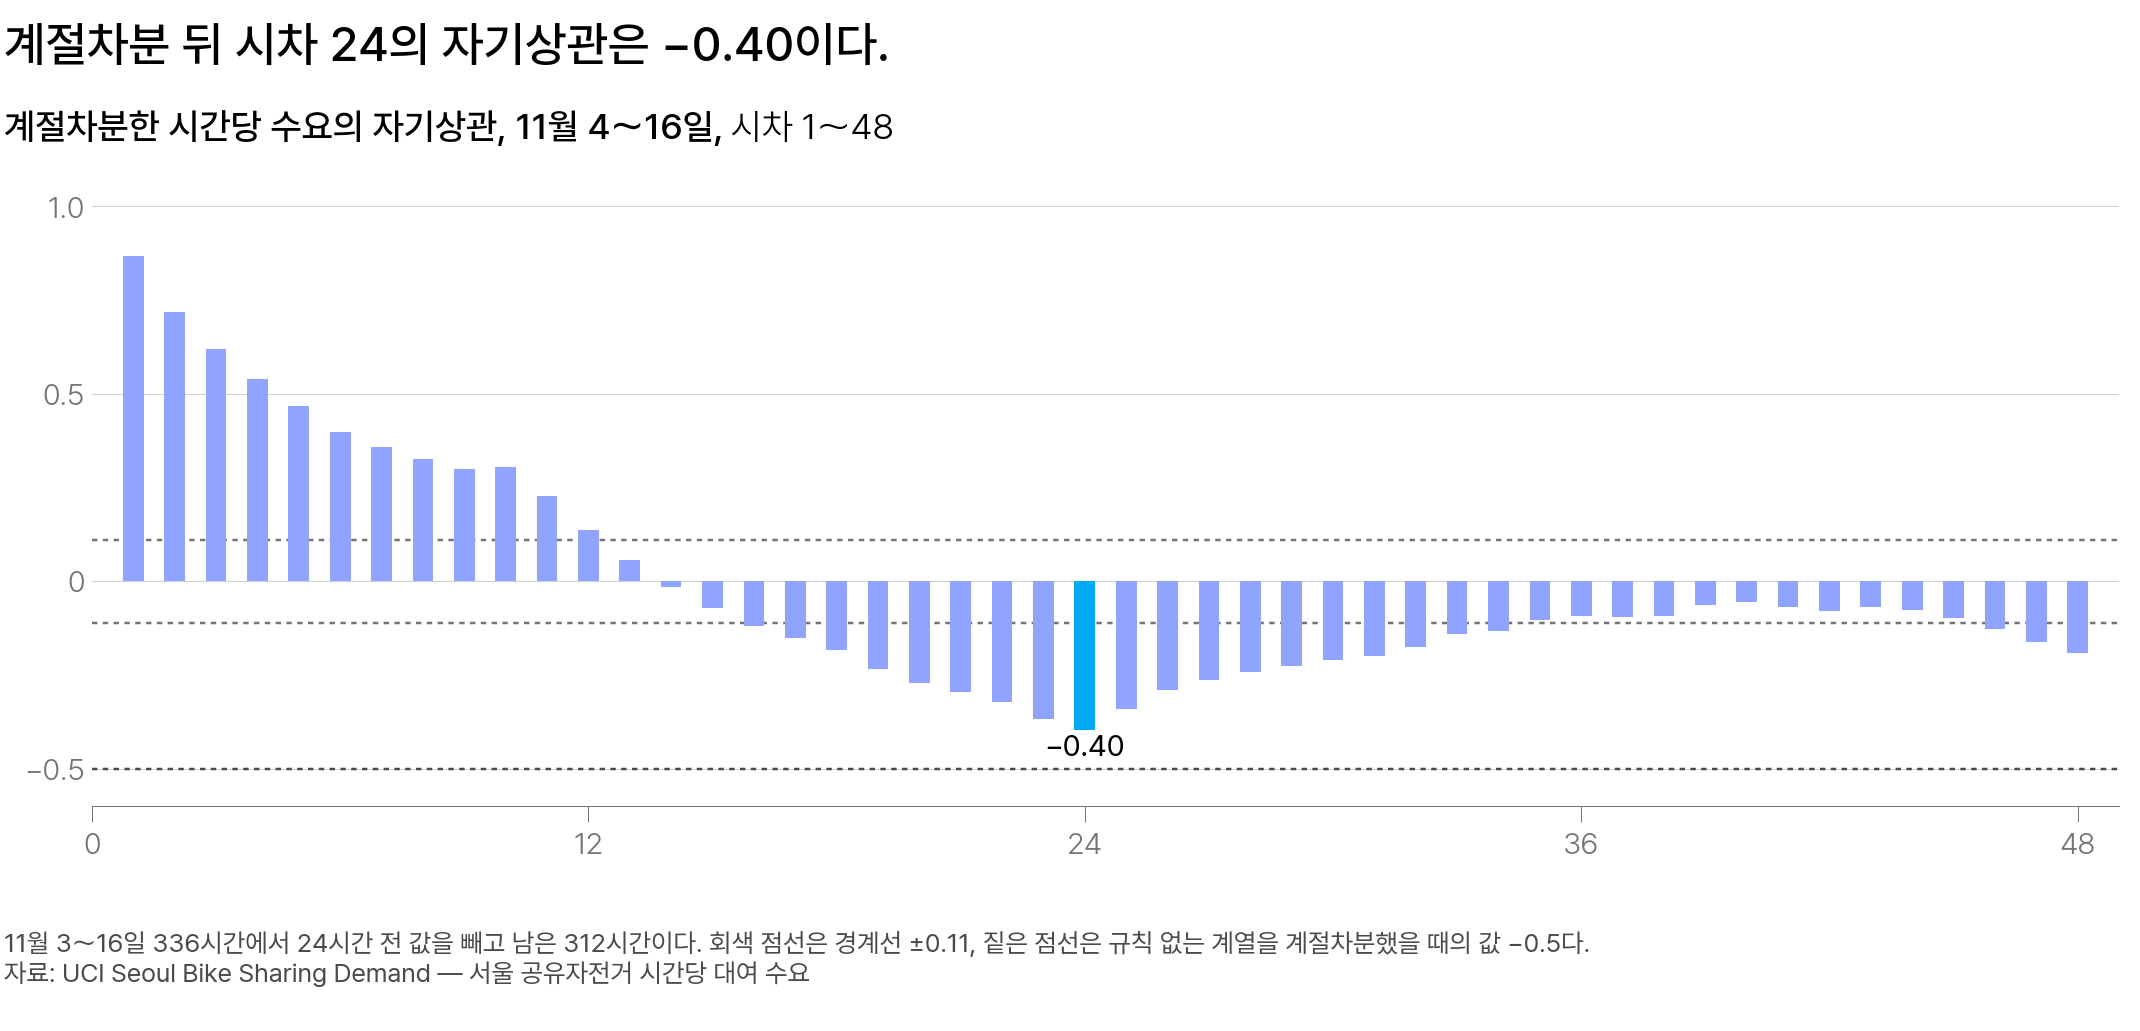

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 서울 336시간을 계절차분한 312시간의 자기상관. 시차 24 의 자기상관이 −0.40 이고, 규칙 없는 계열을 계절차분했을 때의 값 −0.5 에 가깝다</em></p>

#### 왜 계절차분 뒤 시차 24 에 큰 음의 자기상관이 남는가

가로축이 시차이고 세로축이 그 시차의 자기상관입니다. 시차 1 부근의 큰 양의 막대는 이웃 시각끼리 닮아서 생기고, 어제 AR 항이 설명했습니다. 예측 질문의 답은 셋째 보기, **큰 음수가 된다** 입니다. 시차 24 의 자기상관은 −0.40 으로 경계선 −0.11 보다 훨씬 작습니다.

전날 같은 시각이면 대여량이 비슷할 텐데 왜 음수일까요? 비슷하다는 생각은 맞습니다. 다만 이 그림은 대여량이 아니라 계절차분한 값을 비교합니다.

- 수준: 대여량 $y_t$. 전날과 비슷합니다
- 변화량: 계절차분한 값 $y'_t$. 이 그림이 비교하는 값입니다

예를 들어 어제 8시 1,000대, 오늘 8시 1,020대, 내일 8시 1,000대라면 계절차분한 값은 +20 → −20 입니다. 오늘 더 나간 20대가 오늘 차분에는 더해지고 내일 차분에서는 빠집니다.

엘리베이터로 보면 이렇습니다.

| 날 | 엘리베이터 위치 | 전날과의 이동량 |
|---|---|---|
| 첫째 날 | 10층 | 해당 없음 |
| 둘째 날 | 12층 | +2층 |
| 셋째 날 | 10층 | −2층 |

서울 공유자전거의 11월 14～16일 9시도 같습니다.

- 대여량: 14일 수요일 1,019대 → 15일 목요일 1,300대 → 16일 금요일 991대
- 계절차분한 값: 15일 +281대 → 16일 −309대

원래 수요가 비슷하다는 사실과 전날 대비 변화량이 반대가 된다는 사실은 동시에 성립합니다.

식으로 확인합니다. 값을 계절 성분 $S_t$ 와 규칙 없는 오차항 $\varepsilon_t$ 의 합으로 두면, 하루 모양이 같아 $S_t = S_{t-24}$ 입니다.

$$
y'_t = (S_t + \varepsilon_t) - (S_{t-24} + \varepsilon_{t-24}) = \varepsilon_t - \varepsilon_{t-24}
$$

한 주기 뒤는 $y'_{t+24} = \varepsilon_{t+24} - \varepsilon_t$ 입니다. 같은 $\varepsilon_t$ 가 한 번은 $+$, 한 번은 $-$ 로 들어가 시차 24 의 자기상관은 −0.5 가 됩니다. 이 음의 자기상관을 그대로 두면 잔차에 남습니다.

<details class="lms-extra"><summary>자세히 — 계절차분이 시차 m 의 자기상관을 −0.5 로 만드는 계산</summary>

「오차항만 있는 계열을 계절차분하면 시차 $m$ 의 자기상관이 얼마인가」를 계산합니다. $m = 2$ 로 둡니다. 오차항끼리는 관계가 없고 분산은 모두 $\sigma^2$ 입니다. 시각 3 과 한 주기 뒤 시각 5 의 계절차분한 값은 $y'_3 = \varepsilon_3 - \varepsilon_1$, $y'_5 = \varepsilon_5 - \varepsilon_3$ 입니다.

- 차의 분산: 관계없는 두 값 A, B 는 $\mathrm{Var}(A - B) = \mathrm{Var}(A) + \mathrm{Var}(B)$ 입니다. 빼도 흔들림은 줄지 않고 쌓입니다.
- 공분산 전개: 공분산은 두 값이 함께 움직이는 정도입니다. 관계없는 오차항끼리는 0, 같은 오차항끼리는 그 분산 $\sigma^2$ 입니다. 두 괄호의 항을 하나씩 짝지어 부호를 곱하고, 빼는 항끼리 만나면 − × − = + 입니다.

분산은 오차항을 대입하고, 첫째 규칙으로 더하고, $\sigma^2$ 을 대입해 더합니다.

$$
\mathrm{Var}(y'_3) = \mathrm{Var}(\varepsilon_3 - \varepsilon_1) = \mathrm{Var}(\varepsilon_3) + \mathrm{Var}(\varepsilon_1) = \sigma^2 + \sigma^2 = 2\sigma^2
$$

공분산은 오차항을 대입하고, 둘째 규칙으로 전개하고, 0 과 $\sigma^2$ 을 대입해 더합니다.

$$
\begin{aligned}
\mathrm{Cov}(y'_3, y'_5) &= \mathrm{Cov}(\varepsilon_3 - \varepsilon_1,\ \varepsilon_5 - \varepsilon_3) \\
&= \mathrm{Cov}(\varepsilon_3, \varepsilon_5) - \mathrm{Cov}(\varepsilon_3, \varepsilon_3) - \mathrm{Cov}(\varepsilon_1, \varepsilon_5) + \mathrm{Cov}(\varepsilon_1, \varepsilon_3) \\
&= 0 - \sigma^2 - 0 + 0 = -\sigma^2
\end{aligned}
$$

0 이 아닌 항은 $-\mathrm{Cov}(\varepsilon_3, \varepsilon_3)$ 하나입니다. 예를 들어 $\varepsilon_3 = +3$ 이면 $y'_3$ 에는 +3, $y'_5$ 에는 −3 으로 들어가 두 값이 반대로 움직이고, 그 몫이 이 $-\sigma^2$ 입니다.

상관은 공분산을 두 표준편차의 곱으로 나눈 값입니다. $y'_5$ 의 분산도 $2\sigma^2$ 이라 상관은 $-\sigma^2 / (\sqrt{2\sigma^2} \sqrt{2\sigma^2}) = -\sigma^2 / 2\sigma^2 = -0.5$ 입니다. 아래 셀로 확인합니다.

</details>

In [ ]:
# 서로 관계없는 오차항 1만 개를 계절차분하면 시차 24 의 자기상관이 −0.5 근처인가
import numpy as np
from statsmodels.tsa.stattools import acf

rng = np.random.default_rng(0)
eps = rng.normal(0, 1, 10_000)                                   # 규칙 없는 오차항 1만 개
diff24 = eps[24:] - eps[:-24]                                    # 계절차분: 24시각 전 값을 뺀다
r = acf(diff24, nlags=24, fft=False)                             # 시차 0～24 의 자기상관
print(f"시차 1 {r[1]:+.3f}  |  시차 12 {r[12]:+.3f}  |  시차 24 {r[24]:+.3f}")
assert abs(r[24] + 0.5) < 0.02                                   # 시차 24 만 −0.5 근처

계절 이동평균 항은 한 주기 전 오차항을 가져다 씁니다.

$$
\begin{aligned}
y'_t &= \varepsilon_t - \varepsilon_{t-24} \\
y'_t &= \varepsilon_t + {\color{#1f6feb}\Theta_1} \varepsilon_{t-24}
\end{aligned}
$$

윗줄은 계절차분한 값이고, 아랫줄은 이 항만 둔 식입니다. $\Theta_1 = -1$ 이면 두 줄이 같아지고, 날마다 같은 하루 모양($S_t = S_{t-24}$)에 오차항만 더한 모형이 됩니다. 336시간에 맞추면 $\Theta_1 = -0.99$ 로 −1 에 거의 닿습니다.

<details class="lms-extra"><summary>더 깊이 — 시차 16～34·48 의 막대, 과차분과 다른 점, 계절 차수의 범위</summary>

위 식의 시차 24 자기상관은 $\Theta_1 / (1 + \Theta_1^2)$ 입니다. $\Theta_1 = -1$ 이면 $-0.5$ 로 앞의 계산과 같습니다.

계절차분이 남기는 음의 자기상관은 시차 24 에 나타나고, 과차분의 신호는 시차 1 의 $-0.5$ 입니다.

계절 자기회귀 항 $P$ 의 신호는 계절 이동평균 항 $Q$ 와 반대 모양으로 나옵니다. 부분자기상관함수가 시차 $m$ 에서 한 번 크게 나타났다가 그 뒤로 끊기면 $P$ 쪽을 봅니다. 자기상관함수의 시차 $m$ 이 크게 음수이면 $Q$ 쪽이고, 서울 312시간의 자기상관 그림이 그렇습니다.

시차 24 양옆의 음의 막대(시차 16～34)는 이웃 시각끼리 닮아서 생깁니다. 시차 23 과 25 도 시차 24 와 거의 같은 두 시각을 비교하니 음의 값이 나옵니다. 계절차분이 직접 만든 자기상관은 시차 24 하나입니다.

시차 48 의 −0.19 도 경계선 밖입니다. 이 막대는 계절차분만으로는 생기지 않고, 거의 다 11월 7～12일의 오르내림에서 나옵니다.

비 온 8일과 주말 10·11일에는 수요가 전날 같은 시각보다 줄었습니다. 휴무라 2일 금요일 값으로 채운 9일과 12일 월요일에는 늘었습니다. 10일에 줄고 이틀 뒤 12일에 늘어난 것처럼 이틀 떨어진 두 날의 부호가 반대인 짝이 몰려, 시차 48 이 음수가 됩니다.

한 주에 몰린 일이라 날마다 되풀이되는 규칙으로 보기 어렵습니다. 이 막대까지 맞추려고 계절 이동평균 항을 둘로 늘리면 학습 2주에만 있던 일을 따라가기 쉽습니다. $P$ 까지 정해 맞춘 모형의 잔차에서 시차 48 자기상관은 −0.12 로 줄지만, 경계선 ±0.11 을 겨우 넘어 조금 남습니다.

$P$ 와 $Q$ 는 각각 0 또는 1 로 두고 비교합니다. 계절 계수를 한 모형에 한두 개까지만 두라는 기준은 Nau 의 [「Rules for identifying ARIMA models」](https://people.duke.edu/~rnau/arimrule.htm) 규칙 13 에 있습니다. 여럿 두면 학습 자료에만 맞추거나 계수 추정이 불안정해지기 쉽다는 것이 이유입니다. 계절 모양이 뚜렷하고 일정하면 계절차분을 하라는 기준은 같은 문서의 규칙 12 입니다.

$D$ 를 최대 1 로 두라는 것도 규칙 12 에 있습니다. 계절차분을 2회 하면 관측이 48개 사라지고, 원래 없던 자기상관이 생깁니다([fpp3 9.1](https://otexts.com/fpp3/stationarity.html)).

---

**월별 자료에서 본 같은 모양**

<img src="https://otexts.com/fpp3/fpp_files/figure-html/usemployment3-1.png" width="640" height="352"/>
<p align="center"><em>▲ 미국 레저·숙박업 월별 고용자 수를 계절차분과 레벨 차분으로 평평하게 만든 계열(위)과 그 자기상관함수·부분자기상관함수(아래). 월별 자료라 한 주기가 시차 12 이고, 그 시차의 자기상관이 가장 작은 음수다 (출처: fpp3 9.9)</em></p>

아래 왼쪽 자기상관함수의 가로축이 시차(개월)입니다. 이 계열은 레벨 차분까지 한 것이라 시차 12 의 자기상관이 −0.5 와 같지는 않습니다.

</details>

**그래서 계절 이동평균 항은 $Q = 1$ 입니다.**

$P$ 는 부분자기상관으로 봅니다. 시차 24 의 부분자기상관은 사이 시차 1～23 의 영향을 뺀 뒤 남는 상관이라, 같은 시차의 자기상관 −0.40 과 값이 다릅니다. 이 값이 경계선 밖으로 크게 나오면 $P$ 를 둡니다.

아래 셀은 계절차분한 312시간의 부분자기상관을 시차 24·48 에서 계산하고, $P = 0$ 과 $P = 1$ 두 모형의 AIC 를 계산합니다.

In [ ]:
# 계절차분한 312시간의 부분자기상관(시차 24·48)과 P = 0·1 두 모형의 AIC 를 본다
import warnings
warnings.filterwarnings("ignore")                                # statsmodels 안내문이 결과를 가리지 않게 한다
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import pacf

try:
    raw = load_csv("datasets/SeoulBikeData.csv")                 # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                                # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.index = (pd.to_datetime(raw["Date"], format="%d/%m/%Y")      # 01/12/2017 = 2017년 12월 1일
             + pd.to_timedelta(raw["Hour"], unit="h"))           # 그 행의 시각을 더한다
raw = raw.sort_index()
hourly = raw["Rented Bike Count"].astype(float).mask(raw["Functioning Day"].eq("No"))
hourly = hourly.fillna(hourly.shift(24 * 7))                     # 운영을 멈춘 시각은 1주일 전 같은 시각으로 채운다
demand = hourly.loc["2018-11-03":"2018-11-16"]                   # 학습 구간 336시간
demand.index.freq = "h"

z = (demand - demand.shift(24)).dropna()                         # 계절차분한 값 312개
pc = pacf(z, nlags=48)                                           # 시차 0～48 의 부분자기상관
print(f"부분자기상관  시차 24 {pc[24]:.2f}  |  시차 48 {pc[48]:.2f}  |  경계선 ±{1.96 / len(z) ** 0.5:.2f}")

try:
    res                                                          # 계수 넷으로 17일 0시를 예측한 셀에서 맞춘 P = 1 모형
except NameError:                                                # 그 셀을 건너뛰었으면 같은 차수로 다시 맞춘다
    res = SARIMAX(demand, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24)).fit(disp=False)
p0 = SARIMAX(demand, order=(1, 0, 1), seasonal_order=(0, 1, 1, 24)).fit(disp=False)   # P = 0 모형, 10초 남짓
for name, m in (("P = 0", p0), ("P = 1", res)):
    print(f"{name}  모수 {len(m.params)}개  |  로그우도 {m.llf:,.2f}  |  AIC {m.aic:,.1f}")
assert (round(pc[24], 2), round(pc[48], 2)) == (0.03, 0.09)
assert (round(p0.aic, 1), round(res.aic, 1)) == (4163.3, 4159.3) and round(res.llf - p0.llf, 1) == 3.0

출력의 첫 줄에서 부분자기상관은 시차 24·48 에서 0.03·0.09 로 경계선 ±0.11 안이라, 부분자기상관만 보면 $P = 0$ 쪽입니다. 그래도 둘째 날 본 대로 자기상관 그림은 후보를 좁히는 데까지이고, 확정은 AIC 로 합니다. 부분자기상관은 계절 이동평균 항을 더하기 전의 계열에서 계산한 값이기 때문입니다.

#### AIC: 계수를 하나 더 쓸 만큼 적합이 나아졌나

AIC 는 둘째 날 배운 점수입니다. 자료를 잘 설명할수록 작아지고, 모수가 늘면 커집니다.

$$
\text{AIC} = \underbrace{2k}_{\text{모수 개수만큼 더하는 항}} - \underbrace{2\ln \hat{L}}_{\text{설명한 정도}}
$$

- $k$ : 추정한 모수의 개수입니다. $P = 0$ 모형은 계수 3개와 오차항의 분산으로 4개, $P = 1$ 모형은 5개입니다.
- $\ln \hat{L}$ : 로그우도이고, 클수록 자료를 잘 설명한 것입니다.

> AIC 는 값 하나로는 뜻이 없고, 후보끼리의 차이로 읽습니다. 차이가 2 이하라면 둘을 가르지 않고 항이 적은 쪽을 고릅니다. 2 보다 크면 AIC 가 낮은 쪽을 고릅니다.

$P = 1$ 은 모수가 하나 많아 AIC 에 패널티 2 가 더 붙습니다. 대신 로그우도가 3.0 늘어 AIC 는 2 × 3.0 = 6.0 줄고, 합하면 4,163.3 에서 4,159.3 으로 4.0 낮습니다. 4.0 은 2 보다 커서 $P = 1$ 을 씁니다.

- 장점: 적합이 나아진 정도와 늘어난 모수를 함께 따진 점수 하나로 후보의 순위를 매깁니다.
- 한계: 차분이 다른 후보끼리는 비교하지 못합니다. 로그우도를 서로 다른 계열에서 계산한 셈이라, 자동 탐색의 $D = 0$ 모형과는 AIC 를 비교하지 않았습니다.
- 한계: 후보의 순위만 알려 줍니다. 1위 모형이 규칙을 다 설명했는지는 잔차를 봐야 압니다.

차분 횟수가 같은 후보 차수, 여기서는 $d = 0$, $D = 1$ 인 $P = 0$ 과 $P = 1$ 가운데 하나를 고를 때 AIC 를 씁니다.

맞춘 계수 $\Phi_1$ 은 0.175 로 작아, 부분자기상관의 신호가 약했던 것과 어긋나지 않습니다.

**그래서 부분자기상관은 $P = 0$ 쪽이었지만, 차수는 AIC 로 정해 $P = 1$ 입니다.**

<div class="lms-summary">

**정리**

| 항목 | 서울 공유자전거에서 |
|---|---|
| 어제 모형 | 1시간 전의 값·잔차로 예측, 17일 8시 1,692 + (−2) = 1,690대 |
| SARIMA | 1시간 전과 24시간 전의 값·잔차로 예측, 17일 8시 1,692 + (−344) = 1,348대 |
| $m = 24$ | 하루 전 같은 시각(월요일 8시 → 일요일 8시) |
| $m = 168$ | 1주일 전 같은 시각(월요일 8시 → 지난주 월요일 8시). SARIMA 에는 $m$ 이 하나라 이 주기는 비교 상대인 계절 나이브 168 이 맡는다 |
| 숫자 7개 | $m = 24$(168 은 336시간의 절반을 잃는다), $D = 1$(하루 모양이 1년 내내 유지), $d = 0$(ADF −17.0), $Q = 1$(시차 24 −0.40), $P = 1$(AIC 4,163.3 대 4,159.3) |

ARIMA 는 1시간 전의 값과 잔차로, SARIMA 는 여기에 24시간 전의 값과 잔차를 더해 예측합니다.

</div>

> **[문제] 계절차분 계산**
>
> 시간 단위 자료에 $m = 24$, $D = 1$ 인 계절차분을 합니다. 어느 날 8시 값은 1,650대, 같은 날 7시 값은 1,200대입니다. 전날 8시 값은 1,580대입니다. ⑴ 이날 8시의 계절차분한 값 $y'_t$ 를 구하세요. ⑵ 세 값 가운데 쓰지 않은 값과 그 까닭을 적으세요. ⑶ 같은 자료를 15분 간격으로 기록했다면, 하루 주기를 적는 $m$ 은 얼마인가요?

## 2. 잔차 진단과 Ljung-Box 검정

앞에서 맞춘 모형은 11월 5일 월요일 8시를 1,303대로 예측했습니다. 실제로는 1,975대가 나가 672대 적게 예측했습니다. 이렇게 빗나간 크기가 336시간 내내 규칙 없이 흩어져 있는지, 평일 아침마다 같은 쪽으로 몰리는지 보는 일이 **잔차 진단**입니다.

### 잔차(residual): 실측값에서 모형의 예측을 뺀 값

직전 시각까지 가진 값으로 다음 한 시각을 예측하고, 그 예측을 실측에서 뺀 차이가 **잔차**입니다. 일기예보가 최고기온을 28도라 했는데 31도가 나왔다면 그날 예보의 잔차는 3도입니다.

모형이 식에 적은 오차항 $\varepsilon_t$ 는 실제로 볼 수 없습니다. 그것을 대신해 수로 계산한 값이 잔차 $e_t$ 입니다.

식으로 적으면 뺄셈 하나입니다.

$$
e_t = \underbrace{y_t}_{\text{그 시각의 실측값}} - \underbrace{\hat{y}_{t \mid t-1}}_{\text{한 시각 앞 예측}}
$$

- $\hat{y}_{t \mid t-1}$ : 시각 $t-1$ 까지 가진 값으로 구한 시각 $t$ 의 예측입니다. $t \mid t-1$ 은 「$t-1$ 까지 알고 $t$ 를 예측했다」고 읽습니다.

앞에서 맞춘 모형의 실제 값(단위: 대)을 대입하면 이렇습니다.

| 시각 $t$ | 실측 $y_t$ | 예측 $\hat{y}_{t \mid t-1}$ | 잔차 $e_t$ |
|---|---|---|---|
| 11월 16일(금) 7시 | 939 | 834 | 939 − 834 = +105 |
| 11월 16일(금) 18시 | 1,956 | 1,718 | +238 |
| 11월 10일(토) 8시 | 589 | 921 | −332 |

잔차 312개의 평균은 12대로, 336시간 실측 평균 789대의 1.6% 라 거의 0 입니다.

모형이 계열의 규칙을 다 설명했다면 잔차에는 아무 규칙도 남지 않습니다. 그런 계열이 **백색잡음(white noise)** 이고, 평균이 0 이며 어느 시차로 비교해도 자기상관이 0 입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/White_noise.svg" width="640" height="480"/>
<p align="center"><em>▲ 백색잡음 1,000개. 0 을 가운데 두고 위아래로 오가며 어느 구간에서도 같은 모양이다 (출처: Wikipedia "White noise")</em></p>

가로축이 관측 순서이고 세로축이 값입니다. 한 값이 컸다고 다음 값이 크지도 않습니다.

### 잔차 진단(residual diagnostics): 잔차가 백색잡음처럼 보이는지 확인하기

잔차는 그림 3개로 봅니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/cafres-1.png" width="640" height="395"/>
<p align="center"><em>▲ 진단을 통과한 잔차. 자기상관 막대가 모두 경계선 안이다 (자료: 중앙아프리카공화국 연별 수출 비중 58개 · 출처: fpp3 9.7)</em></p>

fpp3 는 시계열 예측 교재 『Forecasting: Principles and Practice』 3판의 약칭입니다. 저자는 Hyndman·Athanasopoulos 입니다. 괄호 속 수는 그 책의 목차 번호이고, [otexts.com/fpp3](https://otexts.com/fpp3/) 에서 무료로 읽을 수 있습니다.

| 그림 | 가로축 · 세로축 | 보는 것 | 어긋나면 |
|---|---|---|---|
| 잔차 계열(위) | 연도 · 잔차 | 평균이 0 근처인가 | 모든 예측에 그 평균만큼 더해 고친다 |
| 자기상관함수(왼쪽 아래) | 시차 · 그 시차의 자기상관 | 경계선 밖으로 나간 막대가 있는가 | 더해서는 고칠 수 없어 모형을 바꾼다 |
| 히스토그램(오른쪽 아래) | 잔차 값 · 그 값이 나온 횟수 | 0 을 가운데 두고 좌우가 비슷하게 줄어드는 종 모양인가 | 예측이 한쪽으로만 빗나간 것이라, 뒤에서 만들 예측의 범위도 한쪽으로 치우친다 |

경계선 $\pm 1.96/\sqrt{T}$ 는 관측 58개인 이 그림에서 $\pm 1.96/\sqrt{58} = \pm 0.26$ 이고, 가장 멀리 나간 시차 8 의 −0.21 도 그 안입니다.

평균은 더해서 고칠 수 있지만, 남은 자기상관은 모형을 바꿔야 고칩니다([fpp3 5.4](https://otexts.com/fpp3/diagnostics.html)).

<img src="https://otexts.com/fpp3/fpp_files/figure-html/h02res-1.png" width="640" height="395"/>
<p align="center"><em>▲ 눈으로는 결론이 서지 않는 잔차. 막대 3개가 경계선 바깥이다 (자료: H02 약품 월 처방액 204개월 · 출처: fpp3 9.9)</em></p>

### 왜 눈으로는 결론이 서지 않는가

배치는 앞의 중앙아프리카공화국 수출 비중 잔차 그림과 같고, 왼쪽 아래 자기상관함수의 시차 단위만 개월입니다. 위쪽 잔차 계열은 평균이 0 근처라 볼 것은 자기상관함수입니다.

관측이 204개라 경계선이 $\pm 1.96/\sqrt{204} = \pm 0.14$ 로 좁고, 바깥으로 나간 막대는 23 · 26 · 33개월 시차의 3개입니다.

1.96 은 정규분포에서 가운데 95% 를 자르는 값입니다. 그래서 규칙이 없는 잔차라도 시차 하나가 우연히 바깥으로 나갈 확률이 0.05 입니다. 그린 시차가 36개라 백색잡음이라도 평균 36 × 0.05 = 1.8 개가 바깥으로 나가고, 3개 이상 나갈 확률도 27% 입니다.

- 개수로는 선을 그을 수 없습니다. 3개는 백색잡음에서도 흔히 나오는 개수라, 우연인지 규칙인지 개수만으로는 가를 수 없습니다.
- 개수는 크기를 버립니다. 막대가 경계선을 살짝 넘었는지 멀리 넘었는지, 경계선 안의 막대 여럿이 함께 큰지는 개수에 담기지 않습니다.

그래서 모든 시차의 자기상관 크기를 한 수로 모으는 검정을 씁니다.

### Ljung-Box 검정의 p 값: 잔차에 규칙이 남았나

시차 1부터 정한 시차까지의 자기상관을 모아 수 하나로 만드는 것이 **Ljung-Box 검정**(Ljung-Box test)입니다. 어느 시차든 0 에서 멀면 그 수가 커집니다.

검정이 일단 참이라 두고 시작하는 문장이 **귀무가설(null hypothesis)** 이고, 여기서는 **잔차가 백색잡음이다** 입니다. **p 값**은 그 가설이 참일 때 지금 본 것만큼 극단적인 결과가 나올 확률입니다. 관행인 기준 0.05(유의수준 5%)보다 p 값이 작으면 가설을 버리는 **기각**이고, 크면 통과입니다.

모아 만든 수가 통계량 $Q_{\text{LB}}$ 이고 식은 이렇습니다.

$$
Q_{\text{LB}} = T(T+2) \sum_{k=1}^{L} \frac{\hat{\rho}_k^2}{T-k}
$$

- $Q_{\text{LB}}$ : 자기상관을 모아 만든 수입니다. 앞에서 적은 계절 이동평균 항 개수 $Q$ 와는 다른 기호라 아래 첨자 LB 를 적었습니다.
- $\hat{\rho}_k$ : 잔차의 시차 $k$ 자기상관입니다.
- $T$ : 판단에 쓴 잔차의 개수이고, 아래 코드에서는 312 입니다.
- $L$ : 모아 보는 시차의 끝이고, 아래 코드에서는 24 입니다.

<details class="lms-extra"><summary>자세히 — 왜 자기상관을 제곱해 더하는가</summary>

이 계산은 「자기상관이 하나하나 작아도 여럿이면 합이 커지는가」에 답합니다.

시차 1부터 3까지의 자기상관이 각각 0.2, −0.3, 0.1 이라고 하겠습니다.

그대로 더합니다.

$$
0.2 - 0.3 + 0.1 = 0
$$

부호가 반대인 둘이 서로 지웁니다. 셋 다 0 에서 떨어져 있는데 합은 0 입니다.

제곱하면 부호가 사라집니다.

$$
0.2^2 = 0.04, \quad (-0.3)^2 = 0.09, \quad 0.1^2 = 0.01
$$

세 값을 더합니다.

$$
0.04 + 0.09 + 0.01 = 0.14
$$

이제 어느 시차가 0 에서 멀든 합이 커집니다.

앞의 $T(T+2)$ 와 나누는 $T-k$ 는 잔차 개수에 맞춰 크기를 맞추는 부분입니다. 같은 자기상관이라도 잔차가 많을수록 큰 통계량이 됩니다.

그래서 식이 자기상관을 제곱해 더하는 모양이 됩니다.

</details>

> 앞의 H02 잔차를 fpp3 가 시차 24까지 모아 검정한 p 값은 0.166 입니다. 백색잡음에서도 이만큼 큰 통계량이 여섯 번에 한 번은 나오니 통과입니다.
>
> p 값이 0.001 이라면 백색잡음에서는 천 번에 한 번 나올 만큼 큰 통계량이라, 가설을 기각합니다.

p 값이 작으면 좋은 결과로 읽기 쉽지만, 이 검정에서 작은 p 값은 규칙이 남았다는 뜻입니다.

관측 $T = 100$ 개인 계열의 시차 1～3 자기상관이 0.2, −0.3, 0.1 이라 하겠습니다. $L = 3$ 으로 모으면 통계량은 이렇습니다.

$$
Q_{\text{LB}} = 100 \times 102 \times \left(\frac{0.2^2}{99} + \frac{0.3^2}{98} + \frac{0.1^2}{97}\right) = 14.5
$$

백색잡음에서 통계량이 14.5 이상 나올 확률, 곧 p 값은 0.002 입니다. 0.05 보다 작아 규칙이 남았다고 봅니다. 자기상관이 절반인 0.1, −0.15, 0.05 라면 통계량은 3.6, p 값은 0.30 이라 통과입니다.

- 장점: 여러 시차의 자기상관을 크기까지 한 수로 모읍니다. 경계선 밖 막대의 개수로는 결론이 서지 않을 때 판단을 내려 줍니다.
- 한계: 모아 보는 시차 $L$ 까지만 봅니다. 월별인 H02 는 주기 12 의 2배인 $L = 24$ 로 모아, 경계선 밖의 26·33개월 막대가 검정에 들어가지 않았습니다.
- 한계: 어느 시차에 규칙이 남았는지는 알려 주지 않아, 자기상관 그림을 함께 봅니다.
- 한계: p 값이 커도 예측이 정확하다는 뜻은 아닙니다. 남은 규칙이 없다는 것까지만 말하고, 정확도는 예측오차로 따로 측정합니다.

적합을 마친 모형을 예측에 쓰기 전에 이 p 값을 봅니다. 잔차 그림 3개로 눈에 보이는 결함을 먼저 걸러 내고, 눈으로 결론이 서지 않는 부분은 p 값으로 판단합니다.

> **[예측] 서울 공유자전거 수요 336시간에 SARIMA 를 적합한 뒤 그 잔차로 Ljung-Box 검정을 해 보면 p 값은 어느 쪽일까요?**
>
> 1. 0.5 를 넘는 큰 값(예측이 빗나간 크기에 남은 규칙이 보이지 않는다)
> 2. 0.05 아래의 작은 값(규칙이 남았다)
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

In [ ]:
# 336시간에 SARIMA 를 적합하고 그 잔차로 Ljung-Box 검정을 한 번 계산한다
import warnings
warnings.filterwarnings("ignore")                                # statsmodels 안내문이 결과를 가리지 않게 한다
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    raw = load_csv("datasets/SeoulBikeData.csv")                 # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                                # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.index = (pd.to_datetime(raw["Date"], format="%d/%m/%Y")      # 01/12/2017 = 2017년 12월 1일
             + pd.to_timedelta(raw["Hour"], unit="h"))
raw = raw.sort_index()
hourly = raw["Rented Bike Count"].astype(float).mask(raw["Functioning Day"].eq("No"))
hourly = hourly.fillna(hourly.shift(24 * 7))                     # 운영을 멈춘 시각은 1주일 전 같은 시각으로 채운다
demand = hourly.loc["2018-11-03":"2018-11-16"]                   # 학습 구간 336시간
demand.index.freq = "h"

res = SARIMAX(demand, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24)).fit(disp=False)
print(acorr_ljungbox(res.resid[24:], lags=[24], model_df=4))

출력의 `lb_stat` 열이 통계량 $Q_{\text{LB}}$ 이고 `lb_pvalue` 열이 p 값입니다. 여기서는 통계량 61.6, p 값 0.000004 입니다. 잔차가 백색잡음이라면 이만큼 큰 통계량은 100만 번에 4번 나온다는 뜻입니다. 0.05 보다 훨씬 작으니 서울 공유자전거 336시간의 잔차에는 규칙이 아직 남아 있습니다.

`lags` 에 적은 24 가 식의 $L$ 입니다. $L$ 을 정하는 규칙은 [fpp3 5.4 「잔차 진단」](https://otexts.com/fpp3/diagnostics.html)에 있습니다. 계절 자료는 한 주기의 2배를 쓰고, 계절이 없으면 10 을 씁니다. 그 값이 잔차 개수의 5분의 1 을 넘으면 5분의 1 로 줄입니다.

| 모아 보는 시차 $L$ | 특징 | 이런 경우에 쓴다 | 서울 공유자전거에서 |
|---|---|---|---|
| 한 주기 24 | 하루 안의 시차만 모읍니다. 이틀 떨어진 규칙은 보지 못합니다 | 새 계절 항이 겨냥한 시차 24 까지 풀렸는지 볼 때 | 위 코드가 쓴 값. 통계량 61.6, p 값 0.000004 |
| 한 주기의 2배 48 | fpp3 가 계절 자료에 권하는 값입니다 | 계절 자료의 기본값 | 312개의 5분의 1 이 62 라 48. 통계량 83.2, p 값 0.0003 으로 24 와 결론이 같습니다 |
| 1주일 168 | 0 에 가까운 시차가 많이 들어가 검정이 둔해집니다 | 요일 규칙을 보려는데 잔차가 840개 이상일 때 | 62 를 넘어 규칙에 맞지 않습니다. p 값 0.0043 |

`model_df` 에는 맞춰 둔 계수의 개수를 적습니다. 위 모형은 $p$ · $q$ · $P$ · $Q$ 가 모두 1 이라 4 입니다. 계수를 자료에 맞추면 그만큼 잔차의 자기상관이 0 에 가까워집니다. 그래서 모아 본 시차 24 에서 계수 4 를 뺀 20 을 **자유도**로 두고 판단을 엄하게 합니다.

<details class="lms-extra"><summary>더 깊이 — 기준값 31.4, model_df 4, 앞 24개를 빼는 이유, Box-Pierce</summary>

**4 라는 수.** 추정한 값은 $\phi_1$ 0.79, $\theta_1$ 0.24, $\Phi_1$ 0.175, $\Theta_1$ −0.99 와 오차항의 분산 $\sigma^2$ 다섯입니다. $\sigma^2$ 은 자기상관을 설명하는 계수가 아니라 개수에서 뺍니다.

**31.4 라는 수.** 잔차가 백색잡음이면 이 통계량은 대개 자유도와 비슷한 20 근처에서 나옵니다. 자유도 20 에서 이 통계량이 31.4 를 넘는 일은 100번에 5번뿐입니다. 이 31.4 는 잔차가 백색잡음일 때 통계량이 따르는 카이제곱분포에서 읽은 값입니다.

61.6 은 31.4 의 두 배 가까이라 백색잡음으로 보기 어렵습니다.

**앞 24개를 빼는 이유.** `res.resid[24:]` 는 맨 앞 24개를 뺍니다. 그 24시각은 뺄 24시간 전 값이 없어, 잔차가 초기값을 정하는 과정에서 나온 값이라 크게 흔들립니다. 그 24개까지 포함하면 검정이 규칙을 찾아도 요일 차이 때문인지 출발 구간의 흔들림 때문인지 알 수 없습니다.

---

**Box-Pierce 검정.** Ljung-Box 보다 먼저 나온 검정이고 식이 더 단순합니다. 자기상관을 제곱해 더하는 것은 같은데 앞의 $T(T+2)$ 와 나누는 $T-k$ 가 없습니다. 잔차가 적을 때 판단이 느슨해서 지금은 Ljung-Box 를 씁니다.

</details>

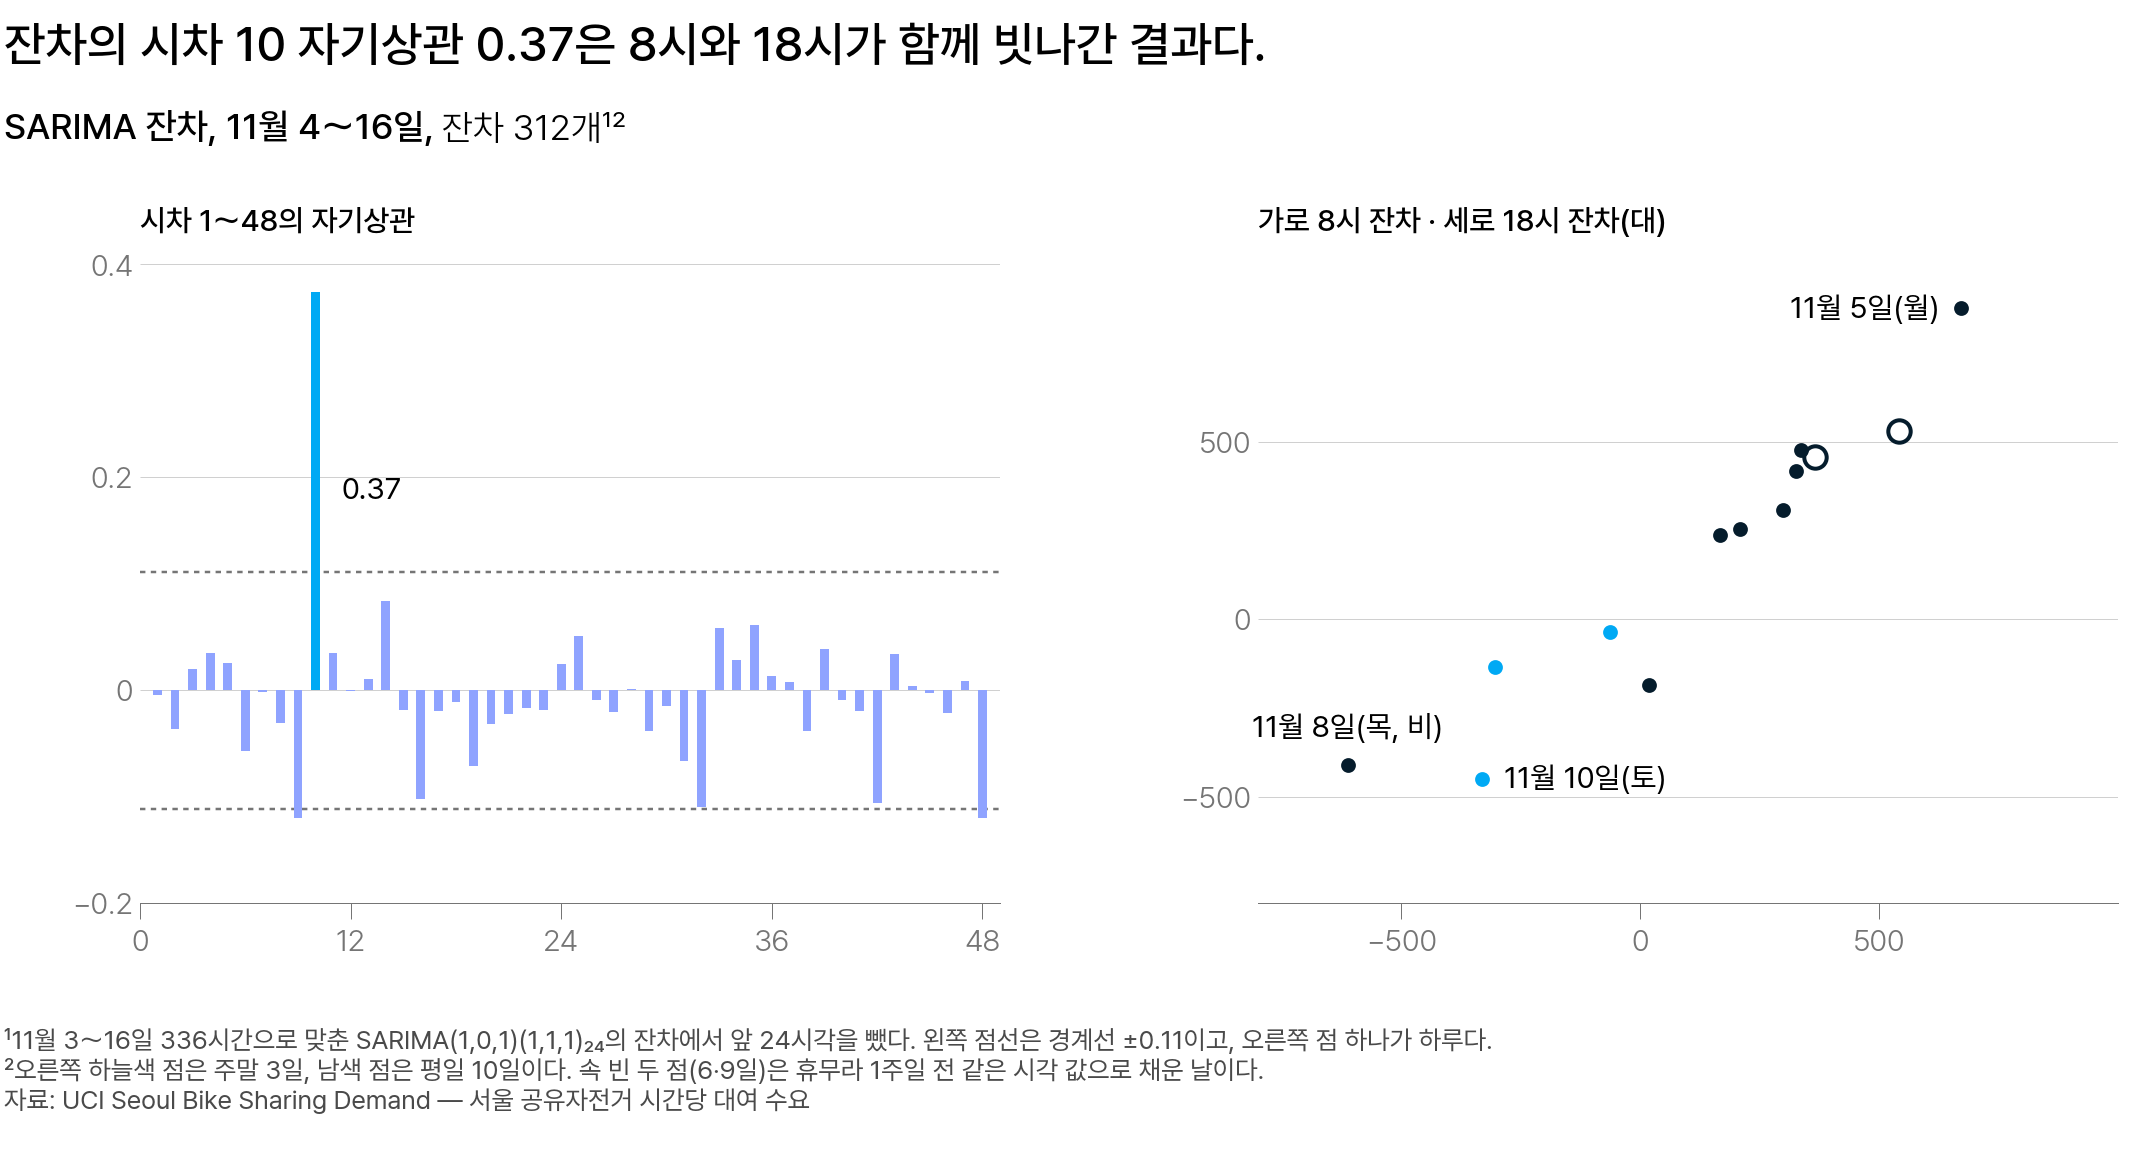

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 잔차 312개의 자기상관(왼쪽)과 하루의 8시·18시 잔차 13일(오른쪽). 시차 9·48 이 −0.12 로 경계선을 겨우 넘고, 크게 나간 막대는 시차 10 의 0.37 하나다. 같은 날 8시와 18시가 함께 위로 또는 함께 아래로 빗나갔고, 함께 아래로 빗나간 하늘색 점 3개가 주말이다</em></p>

왼쪽 그림에서 시차 24 막대는 0.02 로 경계선 안에 들어왔습니다(어제 모형 −0.33).

남은 큰 막대는 같은 날 8시와 18시 사이인 시차 10 의 0.374 입니다. Ljung-Box 식의 합에서 이 막대 하나가 차지하는 몫이 약 45 로, 통계량 61.6 의 약 3/4 입니다.

모형은 평일과 주말을 합친 하루 모양 하나로 예측해, 오른쪽 그림의 13일(11월 4～16일)이 이렇게 갈립니다.

| 날 | 8시·18시 잔차 | 예 |
|---|---|---|
| 평일 6일(5일, 12～16일) | 함께 위로 | 5일 월요일 +672대, +877대 |
| 주말 3일, 비 온 8일 목요일 | 함께 아래로 | 10일 토요일 −332대, −449대 |
| 7일 수요일 | 엇갈림 | +18대, −184대 |
| 6·9일(평일) | 휴무라 1주일 전 값으로 채운 날 | 그림의 속 빈 점 |

잔차 검사를 모두 통과하는 모형을 늘 찾을 수는 없습니다. [fpp3 9.9 「계절 ARIMA 모형」](https://otexts.com/fpp3/seasonal-arima.html)도 그럴 때는 찾은 모형 가운데 가장 나은 것을 쓴다고 적습니다.

<div class="lms-summary">

**정리**

- Ljung-Box 검정: 귀무가설이 「잔차가 백색잡음이다」라 p 값이 0.05 보다 크면 통과
- 오늘 모형: 통계량 61.6, p 값 0.000004 로 통과하지 못했습니다
- 시차 24 의 자기상관: 어제 모형 −0.33, 오늘 모형 0.02
- 남은 규칙: 시차 10(같은 날 8시와 18시)의 자기상관 0.37, 요일 차이

오늘 모형은 시차 24 의 규칙은 설명했지만 요일 차이가 잔차에 남았습니다.

</div>

> **[문제] Ljung-Box 결과를 보고서에 옮기기**
>
> 어떤 모형의 잔차에 Ljung-Box 검정을 해 p 값 0.002 를 받았다고 하겠습니다. ⑴ 이 결과가 모형에 좋은 소식인지 나쁜 소식인지를 이 검정의 귀무가설과 연결해 밝히세요. ⑵ 본문의 H02 잔차 자기상관함수는 그려진 시차 36개 가운데 3개만 경계선 바깥으로 나갔는데도 눈으로는 결론이 서지 않는다고 했습니다. 그 이유를 이 검정이 필요한 까닭과 이어 한 문장으로 적으세요. ⑶ 반대로 p 값이 컸다면 그 사실만으로는 말할 수 없는 것 한 가지를 함께 적으세요.

## 3. 예측구간 — 점 예측 옆에 적는 범위

이 모형은 11월 17일 0시를 654대로 예측합니다. 이 값만으로는 500대가 나와도 이상한 일인지 알 수 없어, 값 옆에 적을 범위가 필요합니다.

### 예측구간(prediction interval): 다음 값이 들어올 범위

일기예보는 내일 최저 기온을 값 하나가 아니라 범위로 알려 줍니다. 시계열에서 그 범위가 **예측구간**이고, 다음에 실제로 관측될 값이 들어올 범위입니다.

$$
\hat{y}_{t+h} \pm 1.96 \times \sigma_h
$$

- $h$ : 학습 마지막 시각에서 몇 시간 뒤를 예측하는지입니다. 24시간 뒤를 예측하면 $h = 24$ 이고, 예측하는 시간 전체를 **예측 기간**(forecast horizon)이라 합니다.
- $\hat{y}_{t+h}$ : 값 하나로 적은 예측인 **점 예측**(point forecast)입니다.
- $\sigma_h$ : 앞으로 관측될 실제 값에서 점 예측을 뺀 값이 **예측오차**(forecast error)입니다. $\sigma_h$ 는 $h$시간 뒤 예측에서 그 오차가 흔들리는 크기입니다. 미래 값은 아직 없으니 적합 구간의 잔차로 어림합니다.
- $1.96$ : 구간 안에 값이 들어올 확률을 몇 %로 할지 정한 것이 **신뢰수준**(confidence level)이고, 여기서는 95% 입니다. 잔차가 정규분포를 따른다고 보면 가운데 95% 가 표준편차의 1.96배 안에 들어오므로 1.96 을 곱합니다. 이 교안은 95% 를 씁니다. 모자라지 않을 대수를 정하려면 실제 값이 구간을 벗어나는 일이 드물어야 합니다.

서울 모형의 11월 17일 0시는 학습 끝에서 1시각 뒤라 $h = 1$ 이고, 점 예측은 654대, $\sigma_1$ 은 176.5대입니다. 1.96 × 176.5 = 346대이니, 654대에서 빼면 **하한** 308대, 더하면 **상한** 1,000대입니다.

In [ ]:
# 336시간에 맞춘 SARIMA 로 11월 17일 24시간을 예측하고 95% 예측구간을 본다
import warnings
warnings.filterwarnings("ignore")                                # statsmodels 안내문이 결과를 가리지 않게 한다
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    raw = load_csv("datasets/SeoulBikeData.csv")                 # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                                # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.index = (pd.to_datetime(raw["Date"], format="%d/%m/%Y")      # 01/12/2017 = 2017년 12월 1일
             + pd.to_timedelta(raw["Hour"], unit="h"))           # 그 행의 시각을 더한다
raw = raw.sort_index()
hourly = raw["Rented Bike Count"].astype(float).mask(raw["Functioning Day"].eq("No"))
hourly = hourly.fillna(hourly.shift(24 * 7))                     # 운영을 멈춘 시각은 1주일 전 같은 시각으로 채운다
demand = hourly.loc["2018-11-03":"2018-11-16"]                   # 학습 구간 336시간
demand.index.freq = "h"

res = SARIMAX(demand, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24)).fit(disp=False)
fc = res.get_forecast(steps=24)                                  # 11월 17일 0～23시
ci = fc.conf_int(alpha=0.05)                                     # 95% 예측구간의 하한과 상한
width = ci.iloc[:, 1] - ci.iloc[:, 0]                            # 구간 길이 = 상한 − 하한
for hr in (0, 2, 5, 8):                                          # 본문이 쓰는 네 시각
    pt = fc.predicted_mean.iloc[hr]
    print(f"17일 {hr}시  점 예측 {pt:,.0f}대  |  95% 예측구간 {ci.iloc[hr, 0]:,.0f}～{ci.iloc[hr, 1]:,.0f}대  |  "
          f"구간 길이 {width.iloc[hr]:,.0f}대  |  상대 구간 길이 {width.iloc[hr] / pt:.2f}")
print("구간 길이  " + "  ·  ".join(f"{h}시간 뒤 {width.iloc[h - 1]:,.0f}대" for h in (1, 2, 6, 24)))
print("예측오차의 표준편차  " + "  ·  ".join(f"{h}시간 뒤 {width.iloc[h - 1] / (2 * 1.96):.1f}대" for h in (1, 2, 6, 24)))
dev = demand - demand.groupby(demand.index.hour).transform("mean")   # 같은 시각의 14일 평균을 뺀 값
print(f"같은 시각 값이 날마다 흔들리는 표준편차 {dev.std(ddof=0):.0f}대")   # ddof=0: 336개로 그대로 나눈다
assert round(fc.predicted_mean.iloc[0]) == 654
assert round(width.iloc[23]) == 1351 and round(dev.std(ddof=0)) == 319

첫 행이 위에서 계산한 0시의 654대와 308～1,000대입니다. `conf_int` 는 이름이 신뢰구간이지만 계산하는 것은 다음에 관측될 값의 범위, 곧 예측구간입니다.

#### 구간 길이: 실제 값이 들어올 범위는 몇 대에 걸쳐 있나

**구간 길이**(interval width)는 예측구간의 두 끝 사이 거리입니다.

$$
\text{구간 길이} = \text{상한} - \text{하한} = 2 \times 1.96 \times \sigma_h
$$

> 95% 예측구간의 길이가 700대라면, 실제 값이 점 예측 위아래 350대 안에 스무 번에 열아홉 번 들어온다고 보는 것입니다.

서울 공유자전거의 17일 0시는 상한 1,000대에서 하한 308대를 뺀 692대입니다. 식의 오른쪽 $2 \times 1.96 \times 176.5$ 로 계산해도 같습니다.

- 장점: 단위가 대라 점 예측·실측과 바로 비교됩니다.
- 한계: 점 예측과 비교하지 않으면 넓은지 좁은지 알기 어렵습니다.
- 한계: 잔차가 정규분포를 따르는 백색잡음이라고 두고 계산합니다. 그 가정이 틀리면 실제 값이 구간에 드는 비율이 95% 와 달라질 수 있습니다.

몇 시간 뒤를 예측하는지, 신뢰수준이 몇 % 인지에 따라 불확실성이 대 단위로 얼마나 달라지는지 비교할 때 구간 길이를 씁니다.

#### 상대 구간 길이: 범위가 점 예측에 비해 얼마나 긴가

**상대 구간 길이**는 구간 길이를 점 예측으로 나눈 값이고, 단위가 없습니다.

$$
\text{상대 구간 길이} = \frac{\text{구간 길이}}{\text{점 예측}}
$$

> 상대 구간 길이가 0.5 라면 범위가 점 예측의 절반이라는 뜻이고, 1 을 넘으면 범위가 점 예측보다 길다는 뜻입니다.

서울 공유자전거 17일의 세 시각입니다.

| 시각 | 점 예측 | 구간 길이 | 상대 구간 길이 |
|---|---|---|---|
| 0시 | 654대 | 692대 | 692 ÷ 654 = 1.06 |
| 8시 | 1,348대 | 1,341대 | 0.99 |
| 5시 | 138대 | 1,304대 | 9.4 |

- 장점: 단위가 없어 수준이 다른 시각끼리 비교할 수 있습니다. 8시는 구간 길이가 0시의 2배에 가깝지만 상대 구간 길이는 0시보다 작습니다.
- 한계: 점 예측이 0 에 가까운 새벽에는 값이 크게 불어납니다(5시 9.4).

이 구간으로 배차 대수를 정할 만한지 가늠할 때 씁니다. 17일 0시처럼 1 을 넘으면 이 구간만 보고 배차 대수를 정하기는 어렵습니다.

### 예측구간이 길어지다가 6시간 뒤부터 거의 늘지 않는 까닭

먼 시각을 예측할수록 덜 확실한 것은 자연스럽고, 앞 코드 셀이 출력한 서울 모형의 구간 길이도 늘어납니다.

- 1시간 뒤: 692대
- 2시간 뒤: 993대
- 6시간 뒤: 1,304대
- 24시간 뒤: 1,351대

그런데 6시간 뒤부터는 거의 늘지 않습니다. 구간 길이 $2 \times 1.96 \times \sigma_h$ 에서 1.96 은 그대로이니, 커지다 멈추는 것은 $h$시간 뒤 예측오차가 흔들리는 크기 $\sigma_h$ 입니다.

쉬운 모의 계열로 $\sigma_h$ 를 따라가 봅니다. 매시각 값은 직전 값에 0.8 을 곱하고 오차항을 더해 만듭니다. 오차항은 그 시각에 새로 생겨 미리 알 수 없는 변동이고, 표준편차가 20 입니다.

**$\sigma_h$ 가 커지는 까닭.** 1시간 뒤를 예측할 때 모르는 것은 그 시각의 오차항 하나라 $\sigma_1 = 20$ 입니다. 2시간 뒤는 두 가지를 모릅니다.

- 2시간 뒤에 새로 생길 오차항: 표준편차 20
- 1시간 뒤의 오차항이 0.8배로 남아 이어진 몫: 표준편차 20 × 0.8 = 16

두 오차항은 서로 관계가 없어, 한쪽이 크게 나올 때 다른 쪽이 작게 나와 상쇄되기도 합니다. 그래서 $\sigma_2$ 는 20 + 16 = 36 이 아니라 $\sqrt{20^2 + 16^2} = 25.6$ 입니다.

**$\sigma_h$ 가 멈추는 까닭.** 오래전 오차항의 영향은 한 시간마다 0.8배씩 줄어 사라집니다. 새로 더해지는 몫이 20, 16, 12.8, … 로 작아져, $\sigma_h$ 는 $20 / \sqrt{1 - 0.8^2} = 33.3$ 에 가까워집니다.

33.3 은 이 계열이 평소에 흔들리는 크기입니다. 먼 시각은 지금 값이 도움이 되지 않아, 그 시각이 평소 흔들리는 만큼만 알 수 있습니다.

기온으로 보면 이렇습니다.

| 언제의 기온을 말하나 | 오늘 기온이 도움이 되나 | 말할 수 있는 범위 |
|---|---|---|
| 내일 | 크게 된다 | 오늘 기온 근처의 좁은 범위 |
| 한 달 뒤 | 거의 안 된다 | 그 무렵의 평년 범위 |
| 두 달 뒤 | 안 된다 | 그 무렵의 평년 범위. 한 달 뒤보다 넓지 않다 |

모의 계열의 구간 길이는 1시간 뒤 78.4, 2시간 뒤 100.4, 6시간 뒤 126.1 이고, 한계는 $2 \times 1.96 \times 33.3 = 130.7$ 입니다.

서울 모형에서는 0.8 대신 한 시간 전 값에 곱하는 계수 $\phi_1 = 0.79$ 가 있습니다. 16일 23시 계절차분한 값의 영향도, 그 뒤 오차항의 영향도 한 시간마다 0.79배로 줄어듭니다. 6시간 뒤에는 $0.79^6 = 0.24$배만 남습니다. 그래서 $\sigma_h$ 는 1시간 뒤 176.5대, 6시간 뒤 332.7대, 24시간 뒤 344.6대에서 멈춥니다.

$\Theta_1 = -0.99$ 라 이 모형은 날마다 같은 하루 모양에 오차항을 더한 모형에 가깝습니다. 그래서 먼 시각에 남는 불확실성은 같은 시각 값이 하루 모양, 곧 같은 시각의 14일 평균에서 벗어나는 크기입니다. 학습 14일에서 그 표준편차는 319대입니다(앞 코드 셀의 마지막 출력 줄). 계산 방법이 달라 344.6대와 같지는 않지만 크기가 비슷합니다.

먼 시각일수록 모르는 오차항은 늘지만 오래된 오차항의 영향이 줄어 사라지므로, 구간은 그 시각이 평소 흔들리는 크기에서 멈춥니다.

<details class="lms-extra"><summary>자세히 — 2시간 뒤 구간 길이를 식으로 계산하기, 계절차분한 모형에서 구간이 멈추는 값</summary>

모의 계열에서 지금이 시각 $t$ 이고 $t+2$ 를 예측합니다. $t+1$ 과 $t+2$ 에 새로 생길 오차항을 $\varepsilon_{t+1}$, $\varepsilon_{t+2}$ 라 합니다. 계열을 만드는 규칙은 $y_{t+1} = 0.8\, y_t + \varepsilon_{t+1}$ 과 $y_{t+2} = 0.8\, y_{t+1} + \varepsilon_{t+2}$ 입니다.

둘째 식의 $y_{t+1}$ 에 첫째 식을 대입하고 괄호를 전개합니다.

$$
\begin{aligned}
y_{t+2} &= 0.8\, (0.8\, y_t + \varepsilon_{t+1}) + \varepsilon_{t+2} \\
&= 0.8^2\, y_t + 0.8\, \varepsilon_{t+1} + \varepsilon_{t+2}
\end{aligned}
$$

점 예측은 모르는 두 오차항을 0 으로 둔 $0.8^2 y_t$ 입니다. 그래서 예측오차는 남은 두 항 $0.8\, \varepsilon_{t+1} + \varepsilon_{t+2}$ 입니다.

- 서로 관계없는 두 값을 더한 값의 분산은 두 분산의 합입니다.
- $0.8\, \varepsilon_{t+1}$ 의 표준편차는 $0.8 \times 20 = 16$ 이라 분산은 $16^2$ 입니다.

두 분산을 더하고 제곱근을 씌웁니다.

$$
\sigma_2 = \sqrt{16^2 + 20^2} = 25.6
$$

구간은 점 예측 위아래로 $1.96 \times \sigma_2$ 씩이라, 구간 길이는 $2 \times 1.96 \times 25.6 = 100.4$ 입니다. 같은 계산을 이어 가면 $\sigma_h^2 = 20^2 (1 + 0.8^2 + 0.8^4 + \cdots)$ 입니다. 괄호 속 합이 $1 / (1 - 0.8^2)$ 에 가까워져, $\sigma_h$ 는 33.3 에서 멈춥니다.

---

**계절차분한 모형에서 구간 길이가 멈추는 값**

서울 모형의 구간 길이는 12시간 뒤 1,350대에 이른 뒤, 24시간 뒤까지 1,352대를 넘지 않습니다. 24시간을 넘으면 계절차분으로 빼는 24시간 전 값도 예측값이라 그 오차가 한 번 더 더해집니다. 다만 $\Theta_1 = -0.99$ 가 그 오차를 거의 다 상쇄해, 48시간 뒤 1,387대, 168시간 뒤 1,392대로 조금만 길어집니다.

</details>

### 왜 하한이 0 보다 작게 나오는 시각이 있는가

11월 17일 2시는 점 예측이 349대인데 하한이 −222대입니다.

예측구간은 잔차가 정규분포를 따른다고 보고 계산합니다. 정규분포는 음수 쪽으로도 끝이 열려 있어 이런 값이 나옵니다. 대여 수요에 음수는 없으니 이 하한은 그대로 쓸 수 없습니다.

<details class="lms-extra"><summary>더 깊이 — 하한이 음수로 나올 때 쓰는 두 가지 방법</summary>

이 구간은 점 예측 348.6대에서 위아래로 570.8대씩 떨어져 있습니다. 하한은 348.6 − 570.8 = −222.2대, 상한은 348.6 + 570.8 = 919.4대입니다.

이 모형은 구간 길이를 몇 시간 뒤인지로만 정합니다. 그래서 구간 길이가 새벽 2시 1,142대, 8시 1,341대로 비슷합니다. 2주 동안 수준이 오르지는 않지만, 하루 안에서는 잔차의 표준편차가 새벽 2～5시 28～51대, 8시 355대로 수준과 함께 커집니다. 수준이 낮은 밤 시각에도 낮 시각과 비슷한 구간 길이를 쓰는 것은 이 차이를 담지 못한 것이라, 로그를 쓸 근거가 됩니다.

이럴 때 쓰는 방법이 둘입니다. 로그로 양수를 지키는 방법은 [fpp3 13.3 「예측이 한계 안에 머물게 하기」](https://otexts.com/fpp3/limits.html)에 있습니다.

| 방법 | 특징 | 이런 경우에 쓴다 | 서울 공유자전거에서 |
|---|---|---|---|
| 로그를 씌워 적합하고 지수로 복원 | 지수는 언제나 양수라 복원한 하한도 양수입니다. 모형을 다시 맞춰야 하고, 0 에는 로그를 씌울 수 없습니다 | 수준이 오르면서 오르내림도 함께 커지는 계열, 0 인 관측이 없는 계열 | 336시간의 최솟값이 12대라 쓸 수 있고, 밤과 낮의 흔들림 차이가 근거입니다. 모형을 다시 맞춰야 해 이 교안은 쓰지 않습니다 |
| 하한을 0 으로 적기 | 모형과 점 예측은 그대로 두고 음수 하한만 0 으로 바꿉니다. 원래 하한은 옆에 함께 적어 구간이 왜 길었는지 남깁니다 | 0 인 관측이 있는 계열, 오르내림이 수준과 함께 커지지 않는 계열, 모형을 다시 맞출 시간이 없을 때 | 17일 2시를 「0～919대(계산값 −222대)」로 적습니다 |

</details>

### 신뢰구간과 무엇이 다른가

예측구간과 자주 헷갈리는 것이 **신뢰구간**(confidence interval)입니다. 같은 조건을 여러 번 되풀이하면 나올 평균, 곧 그 시각에 기대하는 값을 **평균 수준**이라 합니다. 신뢰구간은 그 평균 수준이 들어 있을 범위입니다.

아래 그림은 앞의 모의 계열을 평균 수준 100 을 중심으로 움직이게 둔 것입니다. 이 계열의 평균 수준은 몇 시간 뒤를 묻든 100 하나입니다.

> **[예측] 같은 1시간 뒤를 두고 예측구간과 신뢰구간의 구간 길이를 재면 어느 쪽이 길까요?**
>
> 1. 예측구간이 길다
> 2. 신뢰구간이 길다
> 3. 두 구간의 길이가 같다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 뒤 아래 그림을 봅니다.

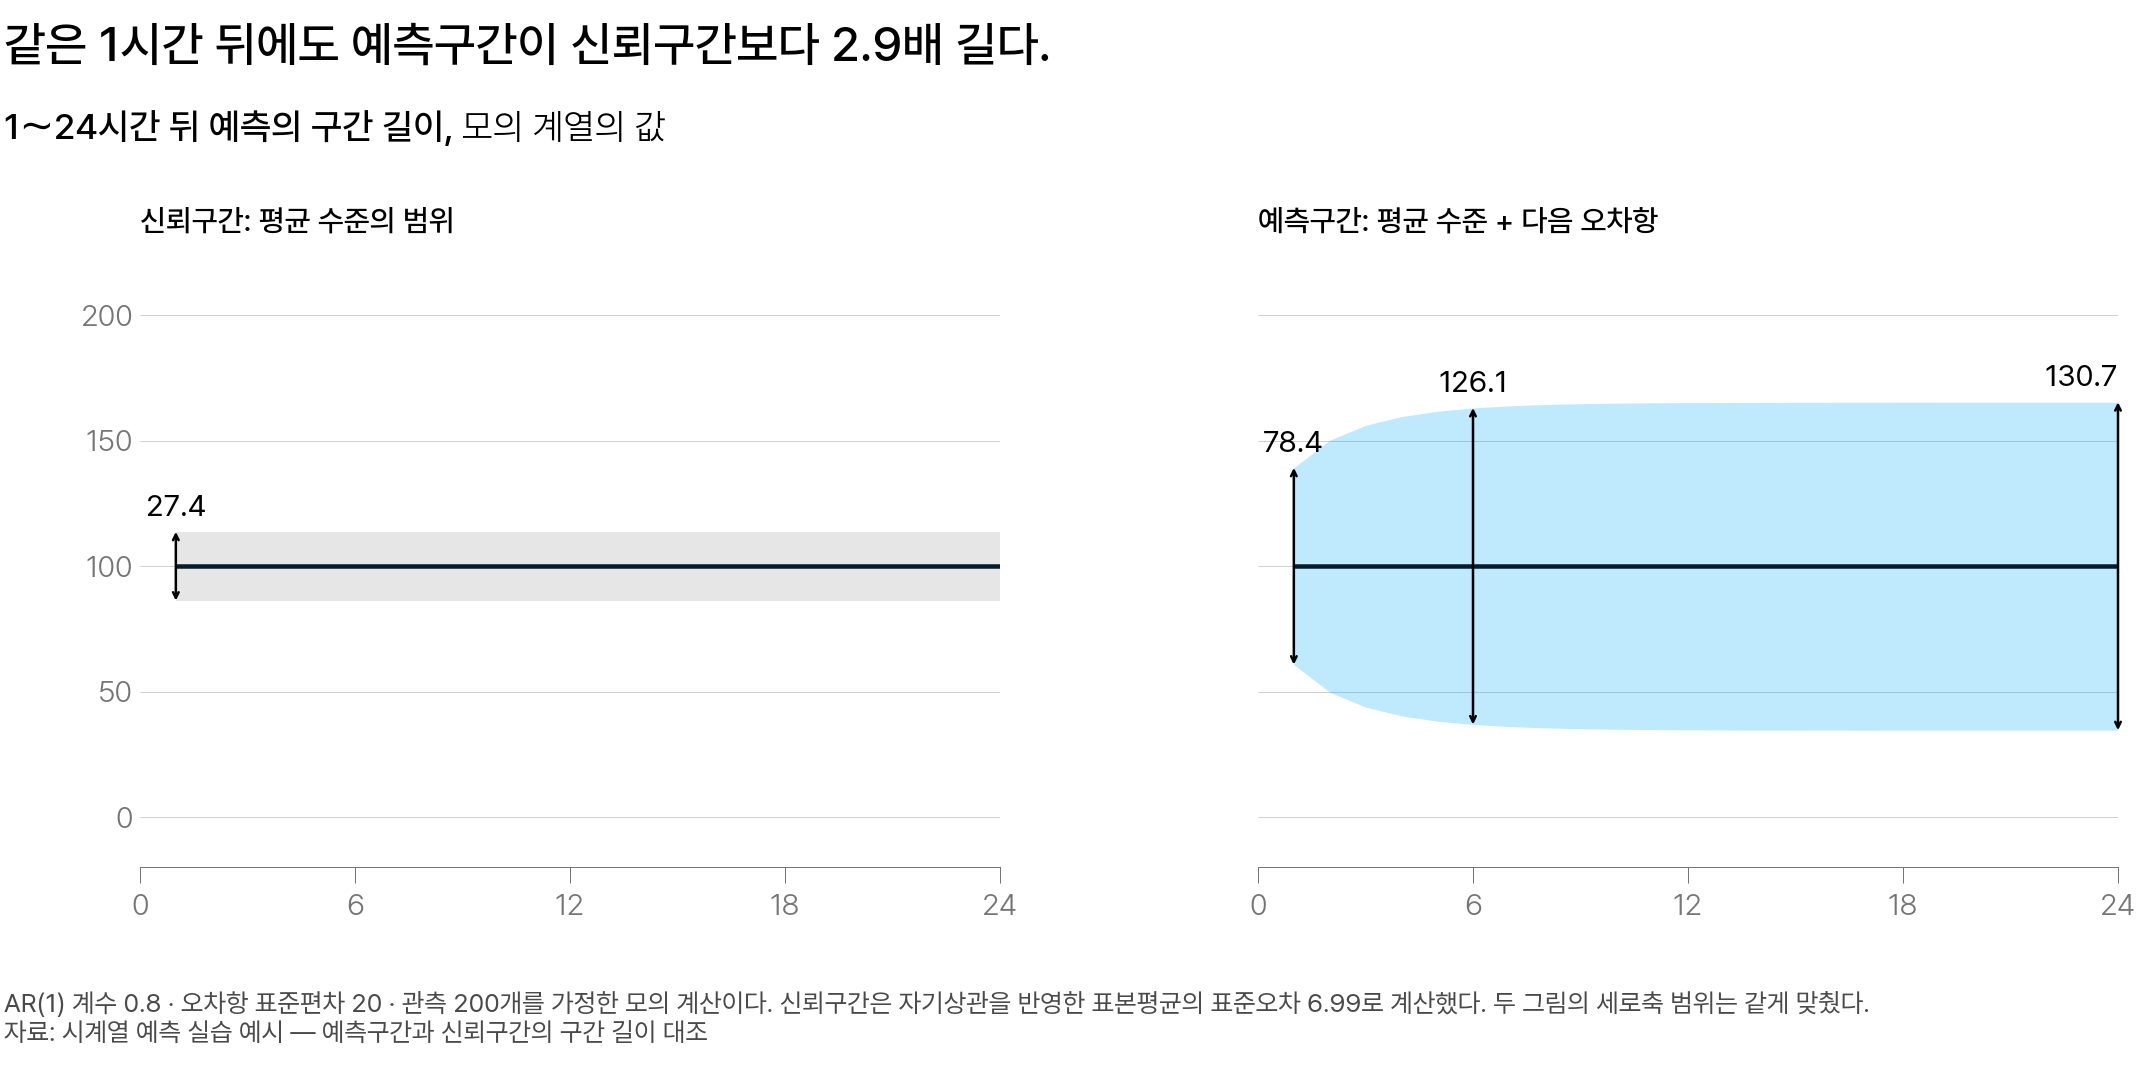

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 예측구간과 신뢰구간. 예측구간은 다음 시각에 발생할 오차항까지 포함해, 같은 1시간 뒤인데 구간 길이가 신뢰구간의 2.9배다</em></p>

예측 질문의 답은 첫째 보기입니다. 1시간 뒤 구간 길이가 신뢰구간은 27.4, 예측구간은 78.4 로 2.9배입니다.

| 비교 | 신뢰구간 | 예측구간 |
|---|---|---|
| 무엇이 들어올 범위인가 | 평균 수준 100 | 다음에 관측될 값 하나 |
| 담는 흔들림 | 평균 수준을 자료로 어림할 때의 흔들림 | 다음 시각에 새로 생길 오차항의 흔들림 |
| 몇 시간 뒤를 묻든 | 길이가 같다. 평균 수준은 값 하나다 | 길어지다가 멈춘다 |
| 서울 공유자전거에서 묻는 질문 | 11월 17일 토요일 8시 수요의 평균 수준은 얼마인가 | 그날 8시에 자전거를 몇 대 채워 두어야 부족하지 않은가 |

**그래서** 데이터를 아무리 모아도 예측구간은 0 으로 줄지 않습니다. 관측을 늘리면 평균 수준은 정확해지지만, 내일 8시에 비가 올지는 오늘 알 수 없습니다.

<details class="lms-extra"><summary>자세히 — 두 구간의 길이 계산, 신뢰수준을 바꾸면</summary>

모의 계열은 직전 값에 0.8 을 곱하고 표준편차 20 인 오차항을 더해 만들었습니다.

**신뢰구간: 평균 수준의 범위**

남색 선이 평균 수준이고 회색 범위가 신뢰구간입니다. 관측 200개로 구한 평균 수준은 참값 100 에서 표준편차로 6.99만큼 흔들리고, 그림 각주의 이 값이 표준오차입니다. 관측이 서로 관계없다면 33.33 ÷ √200 = 2.36 입니다.

그러나 이웃한 관측이 서로 닮아, 200개가 서로 관계없는 200개만큼의 정보를 주지 못합니다. 계수 0.8 인 이 계열에서는 그 탓에 표준오차가 약 3배(√1.8 ÷ √0.2 = 3)로 커져 6.99 가 됩니다. 신뢰구간도 1.96 을 곱해 적지만, 곱하는 것이 $\sigma_h$ 가 아니라 이 표준오차 6.99 입니다. 구간 길이는 2 × 1.96 × 6.99 = 27.4 입니다.

**예측구간: 평균 수준 + 다음 오차항**

남색 선이 점 예측이고 하늘색 범위가 예측구간입니다. 마지막 관측값을 평균 수준 100 과 같게 두어, 점 예측이 100 에서 평평합니다.

이 예측구간은 평균 수준과 계수를 안다고 두고 오차항만으로 계산했습니다. statsmodels 의 예측구간도 계수를 안다고 두고 계산합니다. 평균 수준의 흔들림 6.99 까지 더하면 1시간 뒤는 √(20² + 6.99²) = 21.2 라, 구간 길이가 83.1 로 6% 길어질 뿐입니다.

---

1.96 은 신뢰수준이 95% 일 때의 값입니다. 신뢰수준을 바꾸면 이 수만 바뀝니다([fpp3 5.5 「분포 예측과 예측구간」](https://otexts.com/fpp3/prediction-intervals.html) 표 5.1). fpp3 는 보통 80% 와 95% 구간을 계산합니다.

| 신뢰수준 | 특징(곱하는 수, 모의 계열 1시간 뒤 구간 길이) | 이런 경우에 쓴다 | 서울 공유자전거에서(17일 0시 구간, 길이) |
|---|---|---|---|
| 50% | 0.67, 26.8. 실제 값이 두 번에 한 번 구간을 벗어납니다 | 흔히 오는 범위만 알면 될 때 | 535～773대, 238대 |
| 80% | 1.28, 51.2. 다섯 번에 한 번 벗어납니다 | 가끔 벗어나도 손실이 작고, 범위를 좁게 보는 편이 나을 때 | 428～880대, 452대 |
| 95% | 1.96, 78.4. 스무 번에 한 번 벗어납니다 | 벗어나면 손실이 큰 결정. 이 교안이 쓰는 수준입니다(까닭은 예측구간 식의 1.96 풀이) | 308～1,000대, 692대 |
| 99% | 2.58, 103.2. 거의 벗어나지 않는 대신 가장 넓습니다 | 한 번의 부족도 받아들이기 어려울 때 | 199～1,108대, 909대 |

</details>

<div class="lms-summary">

**정리**

- 17일 0시: 점 예측 654대, 95% 예측구간 308～1,000대
- 구간 길이: 1시간 뒤 692대, 6시간 뒤 1,304대, 24시간 뒤 1,351대
- 예측구간 대 신뢰구간: 같은 1시간 뒤의 구간 길이가 2.9배(모의 계열)

예측값 옆에는 다음 실제 값이 들어올 범위인 예측구간을 함께 적습니다.

</div>

> **[문제] 11월 17일 0시의 95% 예측구간 308～1,000대는 무엇이 들어올 범위인가요?**
>
> 1. 0시 대여 수요의 평균 수준이 들어 있을 범위
> 2. 모형 계수의 참값이 들어 있을 범위를 대 단위로 옮긴 것
> 3. 0시에 실제로 찍힐 대여 수요 하나가 들어올 범위
> 4. 같은 방식으로 자료를 다시 모아 적합할 때 점 예측 654대가 흔들리는 범위

## 4. 서울 공유자전거 적용 — 토요일 24시간 예측은 기준선보다 나은가

11월 3～16일 336시간(2주)으로 계수를 맞추고, 모형이 보지 않은 2018년 11월 17일 **토요일** 24시간으로 채점합니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/traintest-1.png" width="672" height="90"/>
<p align="center"><em>▲ 학습 구간과 채점 구간. 앞 구간(파랑)으로 계수를 맞추고 뒤 구간(주황)으로 채점한다 (출처: fpp3 5.8)</em></p>

가로 화살표가 시간이고 점 하나가 관측 하나입니다. 서울 공유자전거에서 주황은 11월 17일 24시간입니다.

<details class="lms-extra"><summary>자세히 — 원본 8,760시간에서 학습 구간 336시간을 잘라내는 절차</summary>

⑴ **날짜와 시각을 더해 인덱스를 만들고 휴무를 결측으로 둡니다.** 2017년 12월 1일～2018년 11월 30일 8,760시간 가운데 운영 여부 열이 `No` 인 **휴무** 시간은 대여 수요가 0 으로 적혀 있어 결측으로 바꿉니다.

⑵ **1주일 전 같은 시각의 값으로 채웁니다.** 비어 있는 시각에는 168시간 전의 값을 복사합니다. 같은 요일 같은 시각이라 하루 주기와 요일 차이를 동시에 맞춥니다.

1주일 전 같은 시각도 휴무여서 값이 없는 시각만 반대로 168시간 뒤의 값으로 채우며, 2018년 10월 9일 24시간이 그 경우입니다. 이렇게 보정한 열이 `demand` 입니다.

이 채우기는 뒤에서 기준선으로 쓰는 계절 나이브 168 과 같은 규칙입니다. 다만 그 기준선이 가져오는 11월 10일과 채점 대상인 11월 17일에는 휴무로 메운 시각이 하나도 없습니다. 그래서 뒤에서 계산할 계절 나이브 168 의 RMSE 163.5대는 실측만으로 나온 값입니다.

⑶ **구간 2개로 자릅니다.** 11월 3일 0시～16일 23시 336행이 학습 구간, 17일 0～23시 24행이 채점 구간입니다.

</details>

## 기준선(baseline): 계수를 하나도 추정하지 않는 비교 대상

예측이 300대 빗나갔다는 값만으로는 잘한 것인지 알 수 없습니다. 시험 점수 70점도 반 평균이 50점인지 90점인지를 알아야 읽힙니다. 그래서 가장 단순한 규칙으로 만든 예측을 **기준선**이라 하고, 평가표에 언제나 함께 적습니다.

시계열에서 흔히 쓰는 기준선이 **계절 나이브**(seasonal naive)입니다. 한 주기 전 같은 시각의 값을 그대로 예측으로 쓰니, 추정할 계수가 없습니다.

$$
\underbrace{\hat{y}_{t+h}}_{\text{예측값}} = \underbrace{y_{t+h-m}}_{m \text{ 시각 전 같은 시각의 관측값}}
$$

- $m$ : 계절 주기입니다.

$m$ 을 24 로 두면 **계절 나이브 24**, 168 로 두면 **계절 나이브 168** 입니다. 모형은 주기 24 를 쓰지만 기준선은 계절 나이브 168 입니다. 17일이 토요일이라 요일이 같은 1주일 전 값을 가져오기 때문입니다. 11월 17일 토요일 8시라면 이 값을 그대로 씁니다.

- 계절 나이브 24: 16일 금요일 8시의 1,692대
- 계절 나이브 168: 10일 토요일 8시의 589대

<details class="lms-extra"><summary>더 깊이 — 다른 자료로 본 계절 나이브</summary>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/snaive-method-explained-1.png" width="672" height="370"/>
<p align="center"><em>▲ 계절 나이브. 마지막 한 주기의 값 4개(진한 파랑 점)를 그대로 되풀이해 예측(연한 파랑)으로 쓴다 (출처: fpp3 5.2)</em></p>

가로축이 연도이고 세로축이 생산량입니다. 검은 선이 호주의 분기별 벽돌 생산량이고, 한 해에 값이 4개라 $m = 4$ 입니다.

</details>

> **[예측] 평일이 포함된 2주로 학습한 모형이 토요일 아침 8시를 예측하면 어떻게 될까요?**
>
> 1. 실측과 비슷하게 맞힌다
> 2. 평일 출근 시각의 높은 수요를 그대로 예측해 실측보다 크게 높다
> 3. 주말이라 실측보다 낮은 값을 예측한다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

모형이 배운 주기는 24 하나뿐입니다. 이것을 떠올리며 하나 고릅니다.

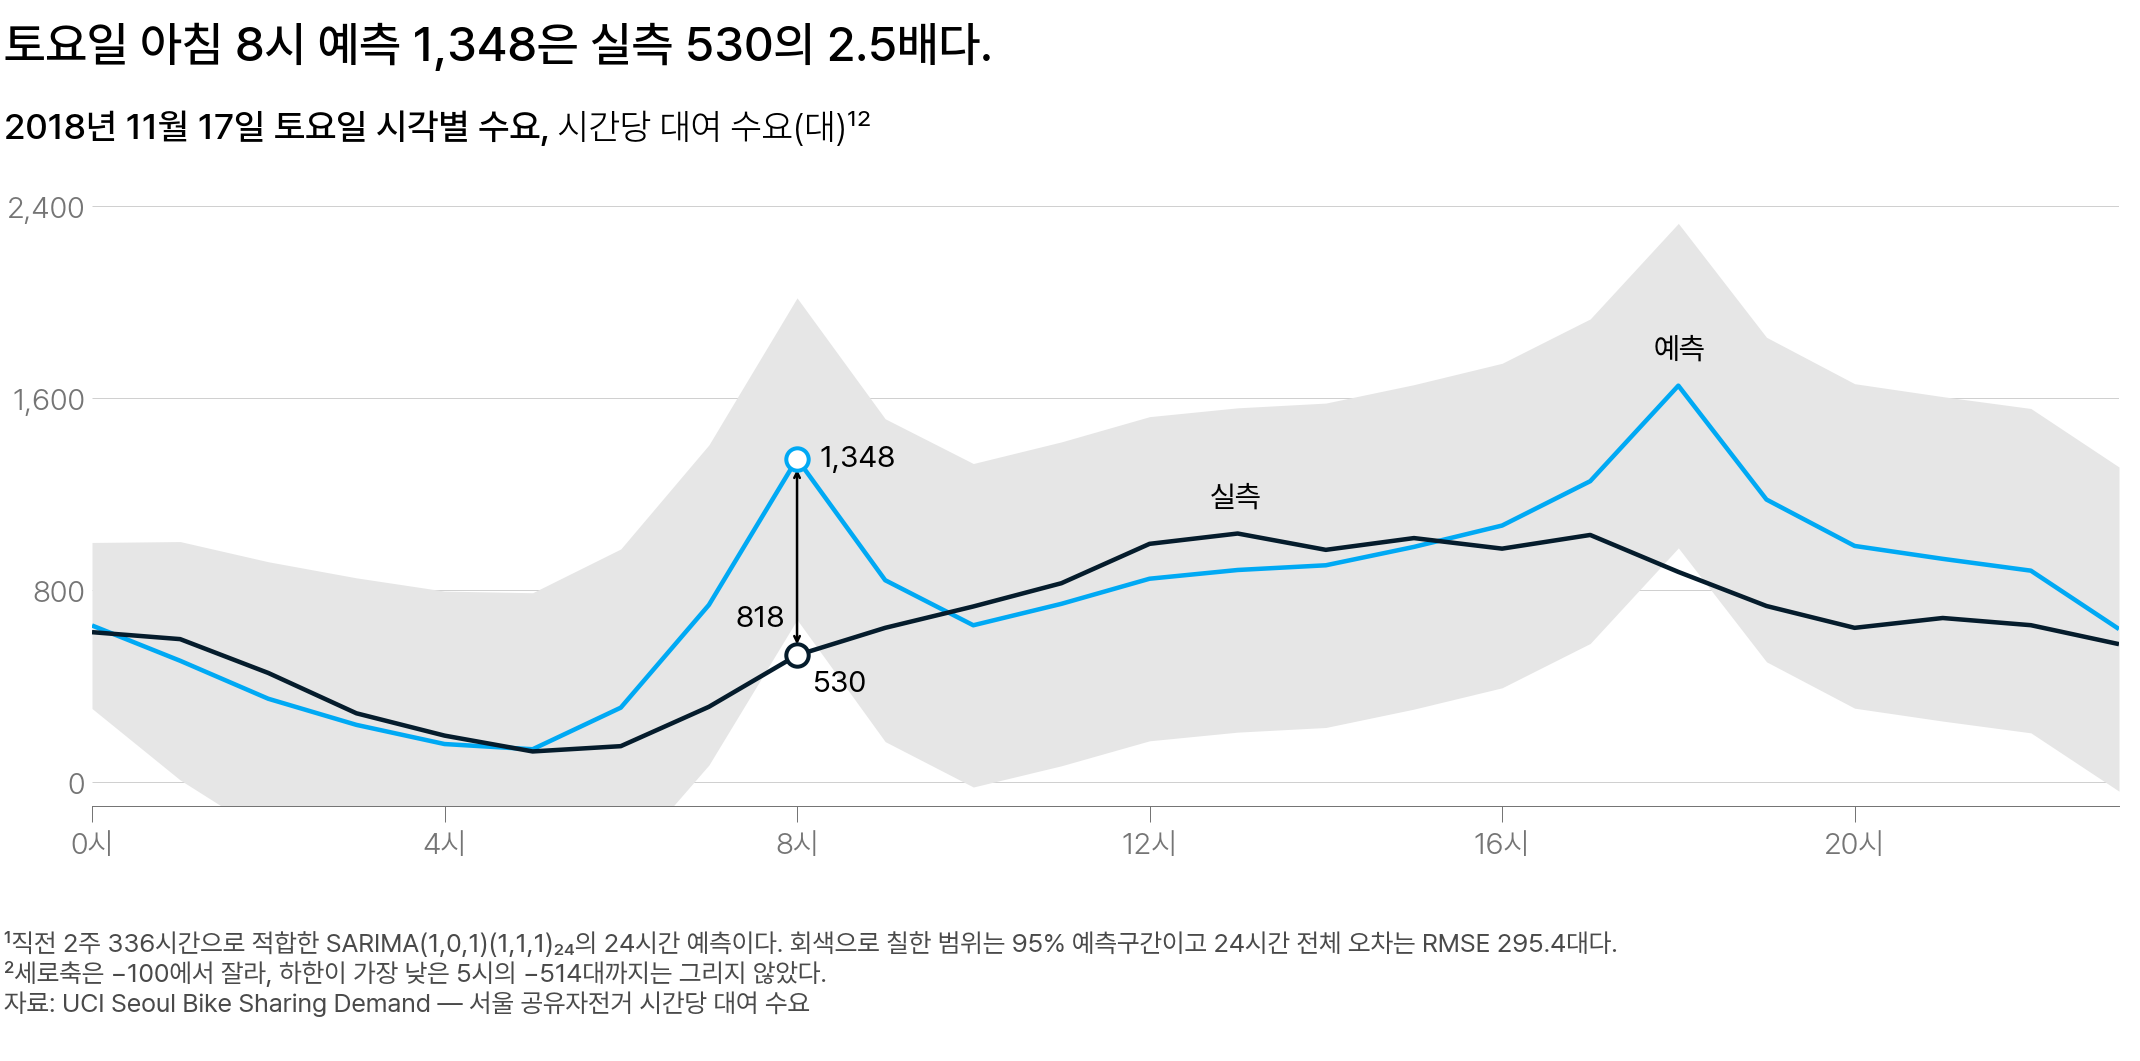

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 2018년 11월 17일 토요일의 실측(남색)과 SARIMA 24시간 예측(하늘색). 회색으로 칠한 범위는 95% 예측구간이다. 새벽 3～5시는 거의 겹치지만 아침 8시에 예측이 1,348대까지 오르는 동안 실측은 530대에 그쳐 818대 차이가 난다</em></p>

#### 예측선과 실측선이 어디서 갈라지는가

예측 질문의 답은 둘째 보기로, 모형이 평일 출근 시각의 높은 수요를 그대로 예측해 실측보다 높습니다.

- **새벽 3시～5시**: 두 선이 거의 겹칩니다. 출근하는 사람이 없어, 학습 2주의 이 시각 평균도 평일 145대와 주말 222대로 77대만 차이 납니다.
- **8시**: 예측이 1,348대까지 오르는데 실측은 530대에 그칩니다.
- **18시**: 예측 1,653대와 실측 877대로 갈립니다.

<details class="lms-extra"><summary>더 깊이 — 채점한 24시간이 95% 예측구간에 든 비율</summary>

24시간 가운데 22시간의 실측이 95% 예측구간 안에 들어왔습니다. 명목 95% 는 24시간이면 22.8시간에 해당합니다. 다만 관측 24개인 하루 표본이라 명목 95% 와 일치하는지는 이 수로 가릴 수 없습니다.

하한은 시각 7개에서 음수가 되고 가장 낮은 곳이 새벽 5시의 −514대입니다. 새벽 2～6시와 10시·23시입니다.

</details>

### 왜 8시 예측이 실측의 2.5배가 되었는가

바로 전날 16일 금요일 8시가 1,692대였으니 예측도 그 근처일 것 같습니다. 전날 값을 옮기는 계절 나이브 24 라면 그렇습니다. SARIMA 는 $\Theta_1 = -0.99$ 라 전날 빗나간 몫의 1%(1 − 0.99)만 반영합니다.

1%만 반영하면 예측이 어떻게 움직이는지 쉬운 수로 봅니다. 예를 들어 어느 시각의 값이 평일 1,600대, 주말 500대이고 지금 예측이 1,300대라 하겠습니다.

| 전날 실측 | 전날 값을 옮기는 규칙 | 1%만 반영하는 규칙 |
|---|---|---|
| 1,600 (평일) | 1,600 | 1,300 + 0.01 × 300 = 1,303 |
| 500 (주말) | 500 | 1,303 + 0.01 × (−803) ≈ 1,295 |
| 1,600 (평일) | 1,600 | 1,295 + 0.01 × 305 ≈ 1,298 |

전날 값을 옮기는 규칙은 날마다 1,100 씩 오르내리고, 1%만 반영하는 규칙은 1,300 근처에서 거의 움직이지 않습니다.

그러면 예측이 머무는 값은 어디서 정해질까요? $\Theta_1 = -1$ 이면 이 모형은 날마다 같은 하루 모양에 오차항만 더한 모형입니다. 같은 값에 흔들림만 더해진 14개 값에서 그 값을 가장 잘 어림하는 것은 14개의 평균입니다. 그래서 −0.99 인 이 모형의 예측도 14일 같은 시각 값의 평균 근처에 머뭅니다.

| 서울 공유자전거 17일 8시 | 값 | 가까운 학습 14일의 8시 평균 |
|---|---|---|
| SARIMA 예측 | 1,348대 | 14일 전체 약 1,298대 |
| 실측 | 530대 | 주말 4일 545대 |

14일 가운데 평일이 10일이라 토요일 8시 예측에도 출근 수요가 들어 있습니다.

<details class="lms-extra"><summary>자세히 — 14일 평균 1,298대의 계산, 전날 더 나간 167.4대가 빠지는 계산</summary>

학습 14일의 8시 평균은 평일 10일 1,599대, 주말 4일 545대입니다. 평일 10일은 운영한 8일에 휴무한 6·9일을 더한 수이고, 그 이틀은 1주일 전 같은 시각 값으로 채웠습니다.

평일 10일의 합과 주말 4일의 합을 더해 14일로 나눕니다.

$$
(10 \times 1{,}599 + 4 \times 545) \div 14 \approx 1{,}298
$$

예측 1,348대는 이 값과 거의 같고, 24개 시각 모두에서 14일 평균과 54대 이내로 다릅니다.

---

16일 8시 실측 1,692대는 그날 예측 1,524.6대에 빗나간 167.4대를 더한 값입니다. 17일 8시 예측에서 새 항은 이 167.4대에 −0.99 를 곱해 더합니다.

새 항의 몫을 곱하고, 16일 8시 실측에 더합니다.

$$
\begin{aligned}
-0.99 \times 167.4 &\approx -165.7 \\
1{,}692 + (-165.7) &\approx 1{,}526
\end{aligned}
$$

더 나간 167.4대에서 새 항이 뺀 165.7대를 빼면 남는 몫이 나옵니다.

$$
167.4 - 165.7 = 1.7
$$

167.4대 가운데 1.7대, 곧 1% 만 남습니다. 그래서 1,526대는 16일 8시 예측 1,524.6대와 거의 같습니다.

17일 8시 예측 1,348대는 이 1,526대에 다른 항의 몫을 더한 값입니다. 한 시간 전 값 −158대, 하루 전 같은 시각의 값 +1대, 25시간 전 값 −8대와 잔차 −25대, statsmodels 계산과 손계산의 차이 +12대입니다.

</details>

SARIMA 는 계절 주기를 1개만 받고, 그 1개를 24 로 썼으니 **주기 168 을 설명하는 항이 모형에 없습니다.**

### 빗나간 정도를 값 하나로 적기 — MAE 와 RMSE

시각마다 실측에서 예측을 뺀 값이 그 시각의 예측오차이고, 24시간을 예측했으니 24개입니다. 방법끼리 비교하려면 이 24개를 값 하나로 줄여야 하고, 줄이는 방법이 둘입니다.

#### MAE: 한 시각에 평균 몇 대 빗나갔나

**MAE**(mean absolute error, 평균절대오차)는 오차의 절댓값을 그대로 평균한 값입니다.

$$
\mathrm{MAE} = \frac{1}{h}\sum_{i=1}^{h}\left|y_{T+i} - \hat{y}_{T+i}\right|
$$

- $y_{T+i}$ : 그 시각의 실측 수요(대)입니다.
- $\hat{y}_{T+i}$ : 같은 시각에 모형이 적은 예측값입니다.
- $T$ : 학습 마지막 시각인 11월 16일 23시입니다.
- $h$ : 예측 기간의 길이이고 여기서는 24시간입니다. $i$ 는 $T$ 에서 몇 시간 뒤인지이고 1～24 입니다.

토요일 예측 그림의 8시는 $T$ 에서 9시간 뒤라 $i = 9$ 입니다. $y_{T+9} = 530$대이고 $\hat{y}_{T+9} = 1{,}348$대이므로, 이 시각의 절대 오차 818대가 24개 가운데 하나로 들어갑니다.

> SARIMA 의 토요일 MAE 는 204.2대입니다. 24시간 동안 한 시각에 평균 204대쯤 실측과 차이가 났다는 뜻입니다.

오차 3개가 +20, −20, +20 대라면 절댓값 20, 20, 20 을 평균해 MAE 는 20대입니다. 절댓값 없이 평균하면 (20 − 20 + 20) ÷ 3 ≈ 6.7대입니다. 반대 부호끼리 지워져 빗나간 크기가 작게 나옵니다.

- 장점: 「한 시각에 평균 몇 대」로 바로 읽히고, 계산이 쉽습니다.
- 장점: 모든 시각을 같은 무게로 봅니다.
- 한계: 큰 오차가 몇 시각에 몰렸는지는 드러나지 않습니다.
- 한계: 단위가 대라서 단위가 다른 계열끼리는 비교하지 못합니다([fpp3 5.8 「점 예측 정확도 평가」](https://otexts.com/fpp3/accuracy.html)).

한 대 빗나갈 때마다 드는 손실이 시각과 상관없이 같을 때 MAE 로 순위를 정합니다. 크게 빗나간 한두 시각에 순위가 좌우되지 않게 하려 할 때도 MAE 를 씁니다.

#### RMSE: 큰 오차에 무게를 더 주면 몇 대 빗나갔나

**RMSE**(root mean squared error, 평균제곱근오차)는 오차를 제곱해 평균한 뒤 제곱근을 씌운 값입니다. 기호는 MAE 와 같습니다.

$$
\mathrm{RMSE} = \sqrt{\frac{1}{h}\sum_{i=1}^{h}(y_{T+i} - \hat{y}_{T+i})^2}
$$

> SARIMA 의 토요일 RMSE 는 295.4대로, MAE 204.2대보다 91대 큽니다. 오차 크기가 시각마다 같으면 두 값이 같습니다. RMSE 가 MAE 보다 클수록 큰 오차가 몇 시각에 몰려 있다는 뜻입니다.

제곱하면 큰 오차가 더 크게 불어납니다. 절댓값의 합이 둘 다 60대인 오차 3개 두 경우로 두 지표를 나란히 계산해 봅니다.

| 오차 3개(대) | MAE(대) | RMSE(대) |
|---|---|---|
| +20, −20, +20 | 20.0 | 20.0 |
| 0, 0, +60 | 20.0 | 34.6 |

아래 행의 RMSE 는 $\sqrt{(0^2 + 0^2 + 60^2)/3} = \sqrt{1{,}200} = 34.6$ 입니다.

- 장점: 크게 빗나간 시각을 무겁게 봅니다. 이 토요일에 8시·18시 두 시각은 절댓값 합의 33% 인데, 제곱 합에서는 61% 입니다.
- 한계: 「평균 몇 대」로는 바로 읽히지 않습니다. [fpp3 5.8](https://otexts.com/fpp3/accuracy.html) 도 RMSE 는 해석하기 더 어렵다고 적습니다.
- 한계: MAE 와 같이 단위가 다른 계열끼리는 비교하지 못합니다.

크게 빗나간 한 번의 손실이 클 때 RMSE 로 순위를 정합니다. 이 교안은 방법의 순위를 RMSE 로 정합니다. 8시에 818대 빗나간 것처럼 크게 틀린 한 시각이 그날 배차를 가장 크게 어긋나게 하기 때문입니다.

| 지표 | 특징 | 이런 경우에 쓴다 | 서울 공유자전거에서 |
|---|---|---|---|
| MAE | 모든 시각을 같은 무게로 | 한 대 빗나갈 때마다 손실이 같을 때 | 204.2대 |
| RMSE | 크게 빗나간 시각에 큰 무게 | 크게 빗나간 한 번의 손실이 클 때 | 295.4대 |

<details class="lms-extra"><summary>자세히 — 두 시각이 RMSE 와 MAE 에서 차지하는 몫</summary>

오차 24개를 제곱해 더하면 209만이고, 8시 818대와 18시 776대의 제곱이 127만입니다. 절댓값을 더한 4,900대에서는 같은 두 시각이 1,595대입니다.

</details>

## 채점한 하루의 오차에도 요일 차이가 나타나는가

적합에 쓴 336시간에서 빗나간 크기가 잔차이고, 채점한 24시간에서 빗나간 크기가 예측오차입니다.

잔차에 남은 요일 차이가 예측오차까지 키웠는지 보려고, 같은 24시간의 시각별 오차를 계절 나이브 168 과 나란히 봅니다.

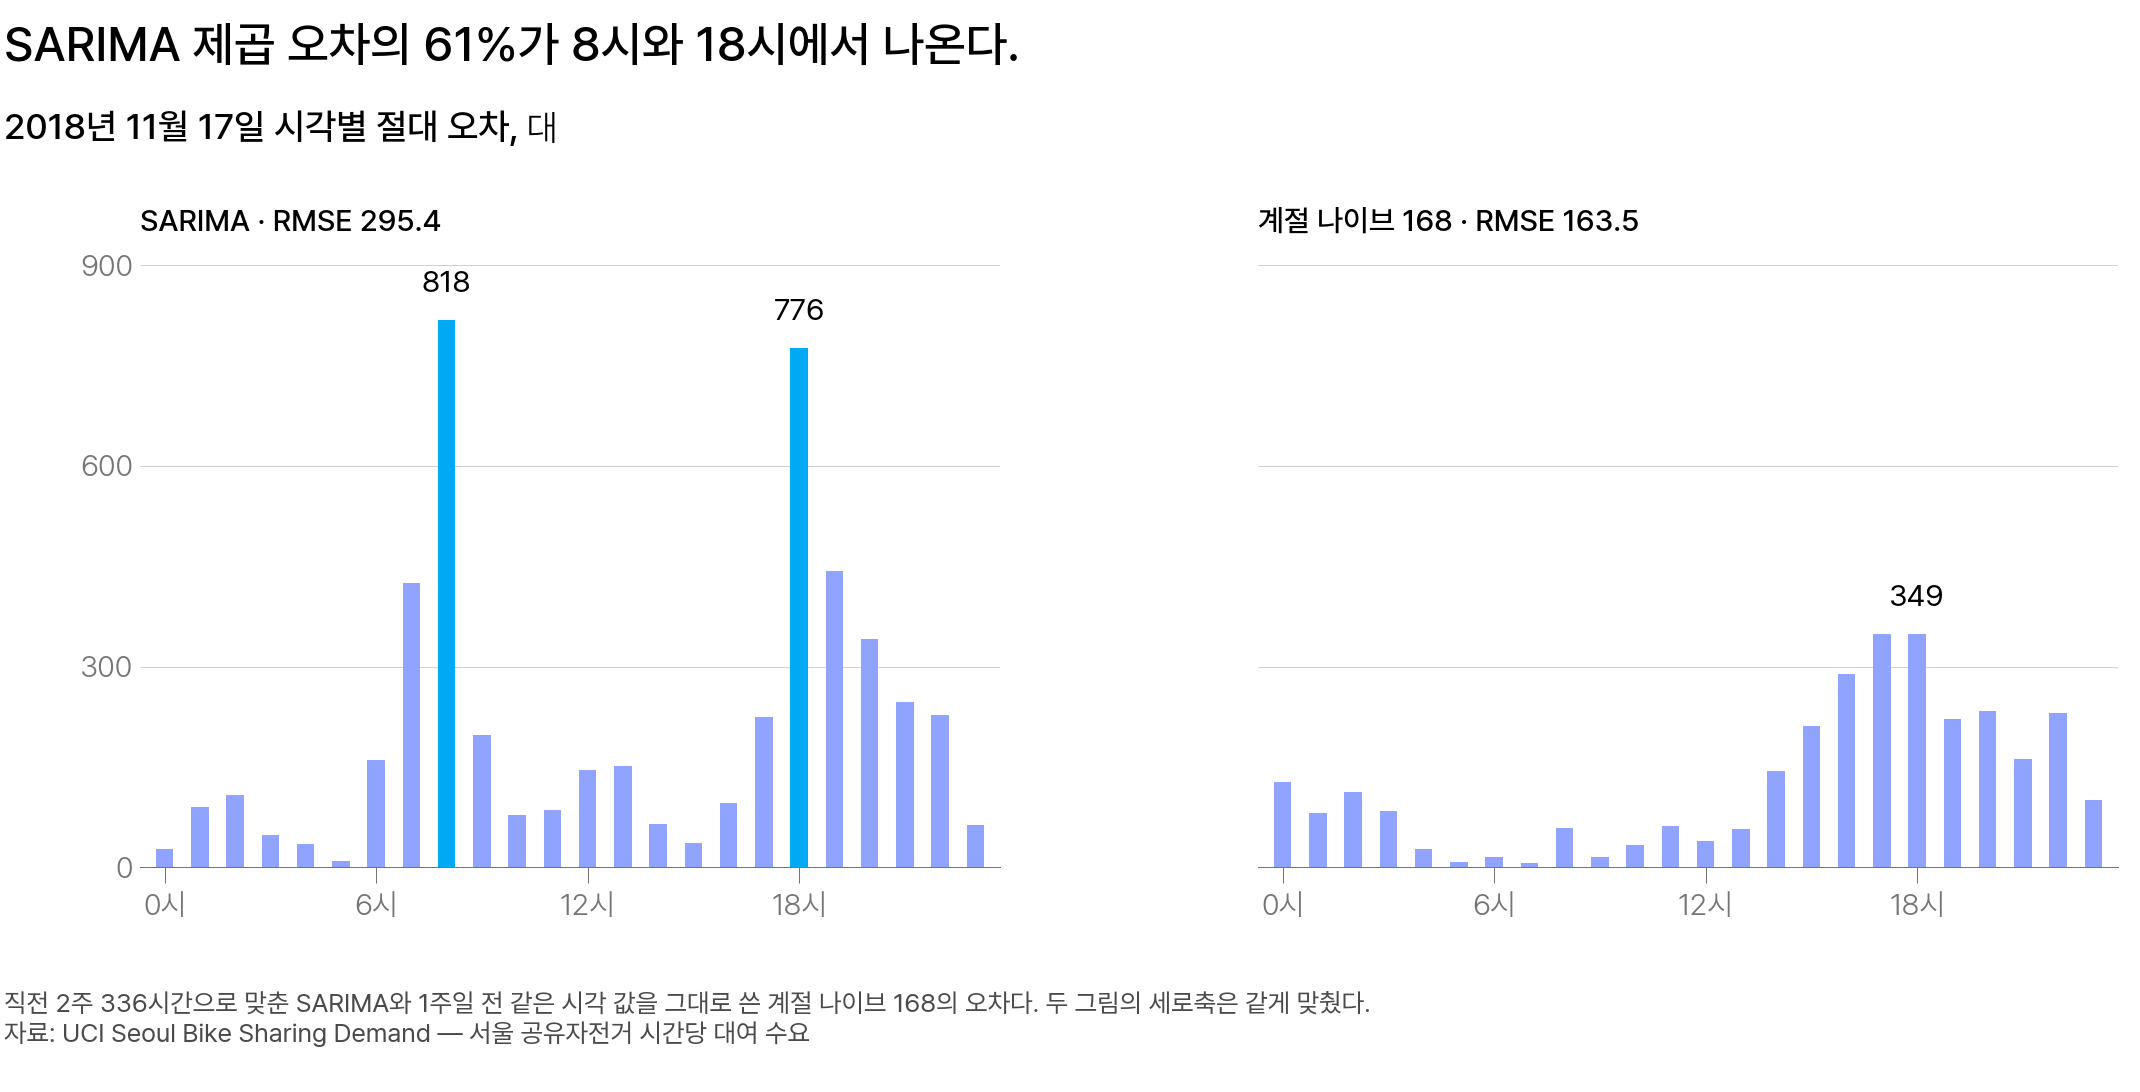

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 같은 토요일 24시간의 시각별 절대 오차. SARIMA(왼쪽)는 8시 818대와 18시 776대에 오차가 몰리고, 계절 나이브 168(오른쪽)은 가장 큰 18시도 349대다</em></p>

요일 차이가 나타납니다. SARIMA 오차는 8시·18시에 몰리는데, 학습 2주에서 평일과 주말의 평균 차이가 가장 큰 두 시각입니다. 계절 나이브 168 은 350대를 넘는 시각이 없어 RMSE 가 163.5대입니다.

| 방법 | 추정한 계수 | 8시 예측(대) | 18시 예측(대) | RMSE(대) |
|---|---|---|---|---|
| 실측 | 해당 없음 | 530 | 877 | 해당 없음 |
| SARIMA(1, 0, 1)(1, 1, 1)$_{24}$ | 4개 | 1,348 | 1,653 | 295.4 |
| 어제 모형: 계절차분 뒤 ARIMA(1, 0, 1) | 2개 | 1,690 | 1,956 | 398.9 |
| 계절 나이브 24 | 0개 | 1,692 | 1,956 | 399.3 |
| **계절 나이브 168** | **0개** | **589** | **1,226** | **163.5** |

<details class="lms-extra"><summary>자세히 — 계수 4개가 줄인 오차, 계절 나이브 24·어제 모형과 비교</summary>

SARIMA 의 계수 4개를 모두 0 으로 두면 식이 $y_t - y_{t-24} = \varepsilon_t$ 만 남아 계절 나이브 24 와 같습니다. 두 방법의 차이는 계수 4개가 만든 것이고, 오차를 399.3대에서 295.4대로 26% 줄였습니다. 계수 2개인 어제 모형은 398.9대였으니, 줄어든 몫은 하루 전 같은 시각의 두 항에서 나왔습니다.

</details>

MAE 로 매겨도 계절 나이브 168 이 125.8대로 SARIMA 의 204.2대보다 낮아 순위가 같습니다.

### 왜 계수 0개인 규칙의 오차가 더 작은가

- **요일이 같은 값**: 계절 나이브 168 은 8시에 11월 10일 토요일 8시의 589대를 그대로 써, 실측 530대와 59대만 다릅니다. 모형이 놓친 요일 차이가 저절로 들어옵니다.
- **하루 전 값**: 계절 나이브 24 가 가져오는 11월 16일은 금요일이라 이 이점이 없습니다.
- **한계**: 계절 나이브 168 은 1주일 전에 특이한 일이 있었으면 그 값을 그대로 이번 주 예측으로 옮겨 오차가 커집니다.

계산 없는 규칙과 같은 지표로 나란히 비교하는 일을 **기준선 비교(baseline comparison)** 라 합니다. 기준선보다 오차가 낮아야 그 모형을 쓸 이유가 생깁니다. SARIMA 의 295.4대는 계절 나이브 168 의 163.5대의 1.8배이니, 오늘 만든 모형은 아직 쓸 단계가 아닙니다.

#### 하루만 채점하고 순위를 정해도 되는가

안 됩니다. 방법별 RMSE 표의 값은 모두 11월 17일 하루에서 나온 값이라, 채점하는 주나 학습 구간 길이가 바뀌면 순위도 바뀔 수 있습니다. 여러 구간에서 나눠 비교하는 방법은 넷째 날에 다룹니다.

<div class="lms-summary">

**정리**

- 17일 8시: SARIMA 예측 1,348대, 실측 530대
- 8시 예측이 높은 까닭: 학습 14일 가운데 평일 10일의 출근 수요가 섞였습니다
- 24시간 RMSE: SARIMA 295.4대, 계절 나이브 168 163.5대

주기 24 하나만 담은 SARIMA 는 요일 차이를 놓쳐 계절 나이브 168 보다 오차가 컸습니다.

</div>

> **[문제] Ljung-Box 를 통과하지 못한 이 모형은 계절 나이브 24 보다도 RMSE 가 높았다.**
>
> O 를 고르고 싶어지는 이유는 Ljung-Box 미통과를 「모든 기준선보다 나쁘다」로 읽었기 때문입니다. p 값 0.000004 는 잔차에 규칙이 남았다는 뜻이고, 오차 순위를 말해 주지 않습니다. 검정 결과와 기준선 대비 오차는 따로 측정하는 값입니다. 자기 답에 세 값 295.4·399.3·163.5 와 이 구별이 들어 있는지 확인해 보세요. 모형 보고서에는 잔차 진단과 기준선 대비 오차를 따로 적습니다. 검정을 통과해도 기준선보다 나쁠 수 있고, 미통과여도 일부 기준선보다는 나을 수 있기 때문입니다.
>
> 1. O (맞다)
> 2. X (틀리다)

## 5. 오늘의 정리와 팀 토론 질문

11월 17일 토요일 24시간 RMSE 는 계절 나이브 168 이 163.5대로 SARIMA 의 295.4대보다 낮았습니다. 그래서 다음 주에 운영에 낼 시간당 예측 대수는 계절 나이브 168 에서 가져옵니다.

### SARIMA 차수를 정하는 순서

| 이런 자료면 | 이렇게 한다 | 서울 공유자전거에서 |
|---|---|---|
| 하루 모양이 날마다 되풀이된다 | 계절차분을 1회 하고, 단위근이 남을 때만 레벨 차분을 더한다 | $D = 1$, ADF −17.0 → $d = 0$ |
| 주기가 둘 이상이다 | 관측을 덜 잃는 주기 하나를 $m$ 에 적는다 | 168 은 336시간의 절반을 잃는다 → $m = 24$ |
| 시차 $m$ 의 자기상관이 크게 음수다 | 계절 이동평균 항을 둔다 | −0.40 → $Q = 1$ |
| 후보가 여럿이다 | 차분 횟수가 같은 후보끼리 AIC 로 고른다 | 4,163.3 대 4,159.3 → $P = 1$ |
| 계수를 맞췄다 | Ljung-Box 로 잔차의 규칙을 본다 | 시차 24까지 모은 p 값 0.000004 → 규칙이 남았다 |
| 계절 이동평균 계수가 −1 에 가깝다 | 예측을 여러 날 같은 시각 값의 평균 근처로 읽는다 | $\Theta_1 = -0.99$, 8시 예측 1,348대(14일 평균 1,298대) |
| 잔차 검정 결과와 상관없이 | 순위는 기준선과 같은 구간의 오차로 정한다 | 295.4대 대 163.5대 |

출처: fpp3 [5.4](https://otexts.com/fpp3/diagnostics.html)·[9.1](https://otexts.com/fpp3/stationarity.html)·[9.5](https://otexts.com/fpp3/non-seasonal-arima.html)·[9.6](https://otexts.com/fpp3/arima-estimation.html), [Nau 「Seasonal ARIMA」 강의 노트](https://people.duke.edu/~rnau/seasarim.htm).

#### 숫자 7개를 행 2개로 읽기

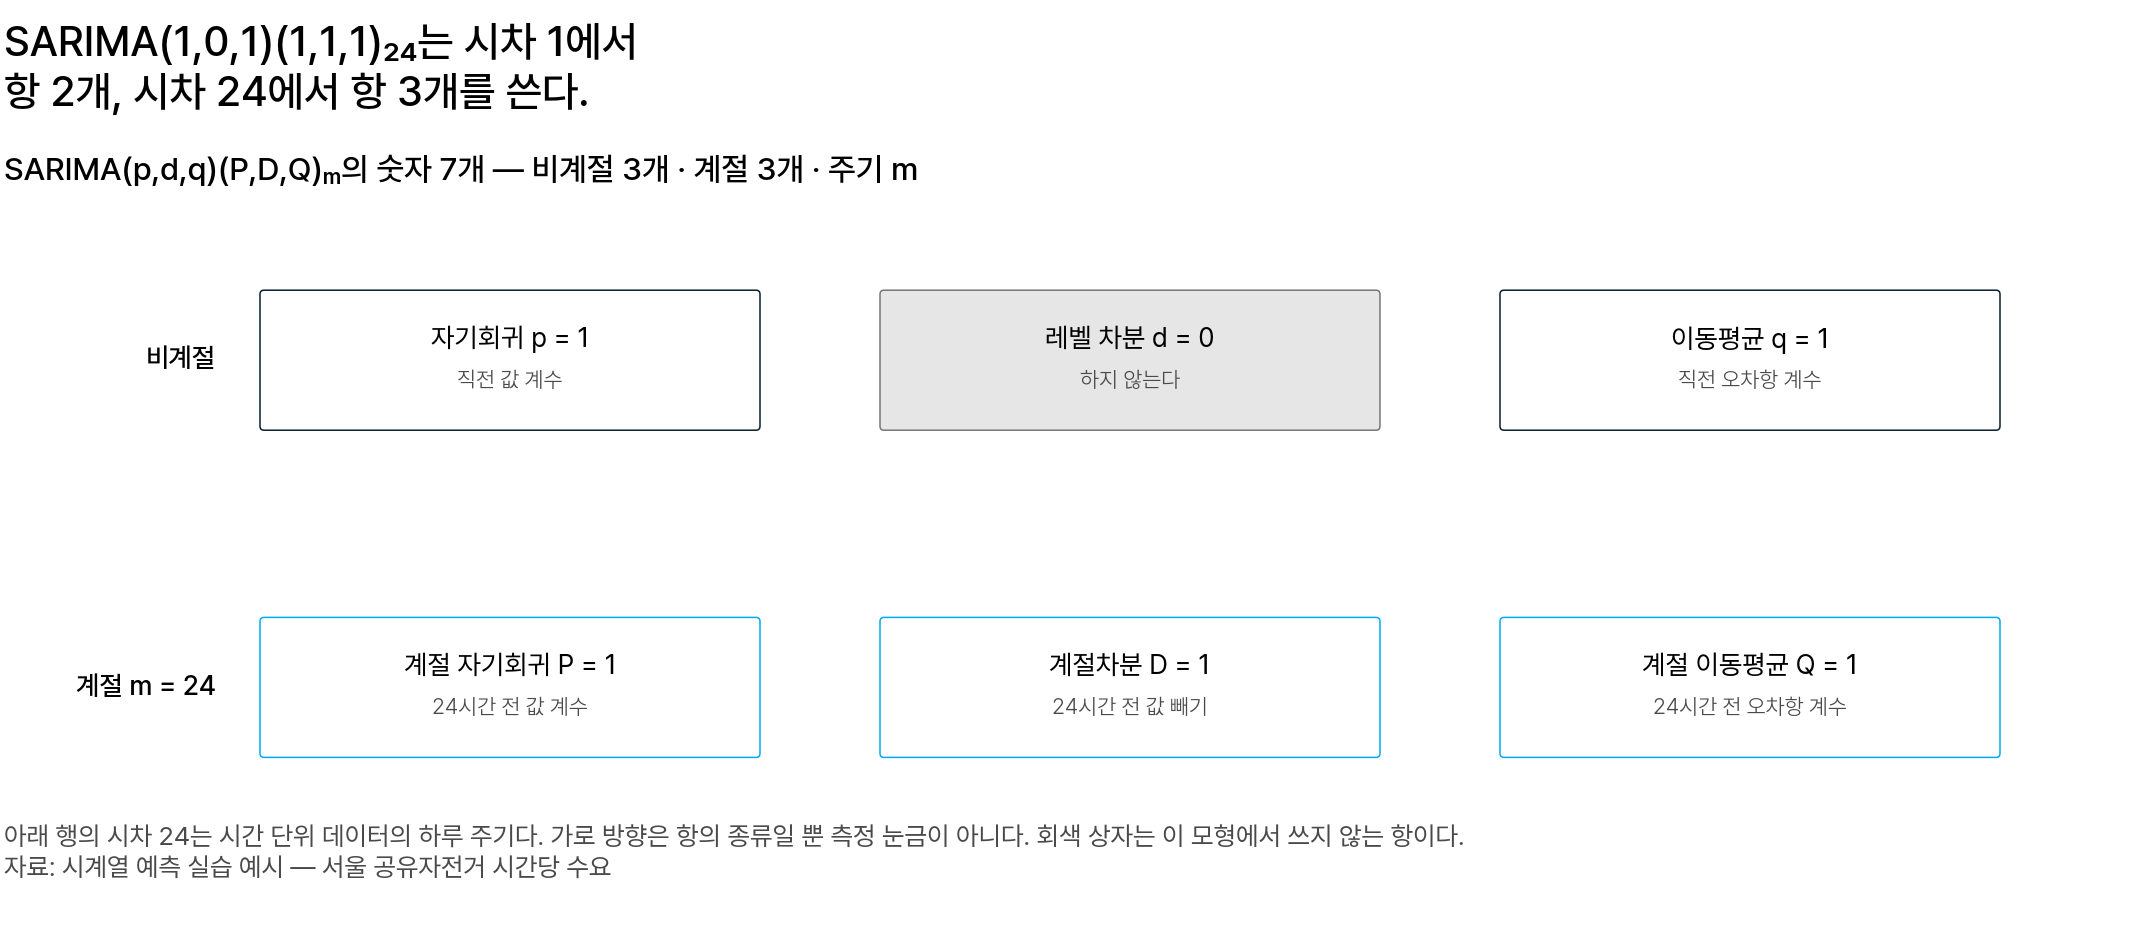

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 오늘 쓴 SARIMA(1, 0, 1)(1, 1, 1)₂₄ 의 숫자 7개. 위 행은 d = 0 이라 항 2개(p·q)만 쓰고, 아래 행은 P·D·Q 3개를 모두 쓴다. 하는 일은 같고 시차만 1 에서 24 로 바뀐다. 일곱째 숫자가 아래 행 왼쪽의 m = 24 다</em></p>

<div class="lms-summary">

**정리**

| 질문 | 답 |
|---|---|
| ARIMA 에 무엇을 더한 것이 SARIMA 인가 | 1시간 전의 값·잔차에 하루 전 같은 시각의 값·잔차를 더한다. 그 개수를 계절 차수 (P, D, Q) 에 적고, 주기는 m = 24 다 |
| 적합을 마친 뒤 무엇을 확인하는가 | 잔차가 백색잡음인지 보고, Ljung-Box p 값이 0.05 보다 커야 통과다 |
| 예측값 옆에 범위를 어떻게 적는가 | 예측구간으로 적는다. 먼 시각을 예측할수록 길어지다가 6시간 뒤부터는 거의 늘지 않는다(24시간 뒤 1,351대) |
| SARIMA 의 오차는 계절 나이브 168 보다 작은가 | 작지 않다. 주기를 하나만 쓸 수 있어 24 를 썼고, 요일 차이를 놓쳤다 |

계절 항을 더하고 잔차까지 확인한 모형도 1주일 전 값을 그대로 쓰는 규칙보다 오차가 클 수 있습니다.

</div>

## 수업에서 다룰 질문

각자 답과 확신도(1～5)를 적어 내면 팀의 답 분포를 함께 봅니다. 그다음 **왜 그 입장을 골랐는지**를 근거 3문장으로 주고받고, 팀의 답 하나를 제출합니다.

> **[문제] 팀 라운드: 기준선보다 RMSE 가 큰 모형을 운영에 쓸 것인가**
>
> 오늘 적합한 SARIMA 는 토요일 24시간 예측에서 RMSE 295.4대가 나왔고, 계수를 하나도 추정하지 않는 계절 나이브 168(1주일 전 같은 시각의 값 그대로)은 163.5대가 나왔습니다. 잔차에 자기상관이 없다는 가정은 Ljung-Box p 값 0.000004 로 기각됐습니다. 같은 24시간에서 실측이 95% 예측구간 안에 들어온 시각은 22시간이고, 1시간 뒤 구간 길이 692대는 같은 시각 예측값 654대보다 깁니다. 운영팀은 다음 주 월요일부터 쓸 예측을 하나 달라고 합니다. 팀 안에서 의견이 3가지로 나뉘었습니다.
> 
> - **관점 A: 지표값이 나은 쪽을 쓴다.** 판단 기준을 미리 RMSE 로 정해 두고 측정했으면 그 결과를 따르는 것이 규율이다. 계절 나이브 168 을 운영에 쓰고, SARIMA 는 다음 후보와 비교할 때까지 보류한다.
> - **관점 B: 예측구간이 필요하니 SARIMA 를 쓴다.** 운영 결정은 점 예측이 아니라 「몇 대까지 대비할까」이고 그것은 구간이 있어야 답할 수 있다. 계절 나이브에는 구간이 없다. 점 예측이 조금 나빠도 구간까지 함께 알려 주는 쪽이 실제로 쓸 수 있는 도구다.
> - **관점 C: 둘 다 아직 이르다.** 24시간 한 번, 그것도 토요일 하루로 순위를 정한 것이다. 요일이 바뀌면 결과도 바뀔 수 있으니 두 방법 모두 보류하고, 같은 조건에서 여러 날을 평가한 뒤에 정하자.
> 
> 자기 입장 하나와 근거 3문장, 그리고 확신도를 정해 오세요.